In [1]:
from histpy import Histogram, HealpixAxis, Axis, Axes
from mhealpy import HealpixMap
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic

from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
# from cosipy.spacecraftfile import SpacecraftFile
# from cosipy.ts_map.TSMap import TSMap
from cosipy.data_io import UnBinnedData, BinnedData
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.ts_map import FastNormFit, FastTSMap
from cosipy.util import fetch_wasabi_file

# cosipy uses astropy units
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from scoords import Attitude, SpacecraftFrame

#3ML is needed for spectral modeling
from threeML import *
from astromodels import Band
import h5py

#Other standard libraries
import os
import glob
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cycler
from matplotlib.gridspec import GridSpec 

import healpy as hp
from tqdm.autonotebook import tqdm

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

10:43:38 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=131528;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=600315;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=158109;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=287185;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


10:43:39 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=676374;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=840768;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=4746;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=971556;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

10:43:41 WARNING   No fermitools installed                                              ]8;id=347322;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=783584;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=902190;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=548794;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=592011;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=272688;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=788551;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=903930;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
import numba
numba.set_num_threads(1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


#### Estimate Cas A Flux

In [ ]:
# See 44-Ti-spectral.ipynb for details

#### Preprocessing

In [ ]:
# hist = Histogram.open('../../DC3/data/responses/extended_source_response_Fe60_low_merged.h5')

# new_axes = []

# axis = hist.axes[0]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

# for axis in hist.axes[1:3]:
#     new_axes += [Axis(np.array([1154, 1160]) * u.keV,
#                     label = axis.label,
#                     scale = axis.axis_scale)]

# axis = hist.axes[3]
# new_axes += [Axis(axis.edges, label = axis.label,
#                   scale = axis.axis_scale)]

# axis = hist.axes[4]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

In [ ]:
# new_hist = Histogram(new_axes,
#                            contents=hist.contents,
#                            sparse=hist.is_sparse,
#                            unit=hist.unit)

# new_hist.write('psr.h5')

In [ ]:
# # Load all 14 weeks of data
# filenames = sorted(glob.glob('../data/*.fits'))
# data_obj.get_binned_data(filenames[0])

# for filename in filenames[1:]:
#     data_loader_obj.get_binned_data(filename)
#     data_obj.binned_data = data_obj.binned_data + data_loader_obj.binned_data

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimensi

In [ ]:
# data_obj.binned_data.write('44Ti_binned_data.hdf5')

### Data Loading

In [2]:
# psr = GalacticResponse.open('psr.h5')
# psr = Histogram.open('psr.h5')
psr_filename = '/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/data/responses/extended_source_response_Ti44_merged.h5'
psr = Histogram.open(psr_filename)


# Create binned data object for sources
data_obj = BinnedData("inputs.yaml")
data_loader_obj = BinnedData("inputs.yaml")


# Create binned data object for background
bg_obj = BinnedData("inputs.yaml")
data_obj.load_binned_data_from_hdf5('44Ti_binned_data.hdf5')
bg_obj.load_binned_data_from_hdf5('../data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')
data = data_obj.binned_data     # Need all 3 months data to use with pre-computed response and background
bg = bg_obj.binned_data


# Crab
crab = BinnedData('inputs.yaml')
crab.get_binned_data(unbinned_data = '../../DC3/Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')

# Cas A
casa = BinnedData('inputs.yaml')
casa.get_binned_data(unbinned_data = 'sources/CasAG16distribution_3months_unbinned_data_filtered_with_SAAcut.fits')


# Alternately, use source injector to create template models
# Use the same pre-computed response file with a fairly representative
# flux. For a narrow 1154-1160 keV energy bin, the exact spectral 
# shape wouldn't matter (i.e., wouldn't impart any biases in the Phi,
# PsiChi axes)
F = 1e-6 * u.ph / u.cm / u.cm / u.s
mu = 1173.2 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


## Image Deconvolution

In [3]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None,
                                    #   is_miniDC2_format=False
                                      )

In [4]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.override_parameter("deconvolution:parameter:iteration_max = 100")
image_deconvolution.override_parameter("deconvolution:parameter:prior:gamma:model:k:value = 0.95")
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/100 [00:00<?, ?it/s]

[{'iteration': 95,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c4e80>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c4a90>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c4670>,
  'background_normalization': {'total': <Quantity 1.04683659>},
  'alpha': 1.0,
  'log-likelihood': [<Quantity -121604.59262093>]},
 {'iteration': 96,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c5f60>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c5780>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c5c59f0>,
  'background_normalization': {'total': <Quantity 1.04682374>},
  'alpha': 1.0,
  'log-likelihood': [<Quantity -121604.58216833>]},
 {'iteration': 97,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49c593a00>,
  'delta_model': <cosipy.image_deconvolu

In [ ]:
cSP = np.geomspace(1e-4, 1e-1, 10)

In [118]:
config_filename = 'MAPdeconvolution.yml'

logL = []
loglambda = []

for c, k in zip(cSP, 1 - cSP):
    # create image deconvolution and run
    image_deconvolution = ImageDeconvolution()
    image_deconvolution.set_dataset([data_interface])
    image_deconvolution.read_parameterfile(config_filename)
    image_deconvolution.override_parameter("deconvolution:parameter:iteration_max = 100")
    image_deconvolution.override_parameter(f"deconvolution:parameter:prior:gamma:model:k:value = {k}")
    image_deconvolution.initialize()
    image_deconvolution.run_deconvolution()

    logL.append(image_deconvolution.results[-1]['log-likelihood'])
    loglambda.append(image_deconvolution.results[-1]['log-prior']['gamma_model']/(-c))

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/100 [00:00<?, ?it/s]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/100 [00:00<?, ?it/s]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


...

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/100 [00:00<?, ?it/s]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/100 [00:00<?, ?it/s]

The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.
The likelihood was not increased in this iteration. The image reconstruction may be unstable.


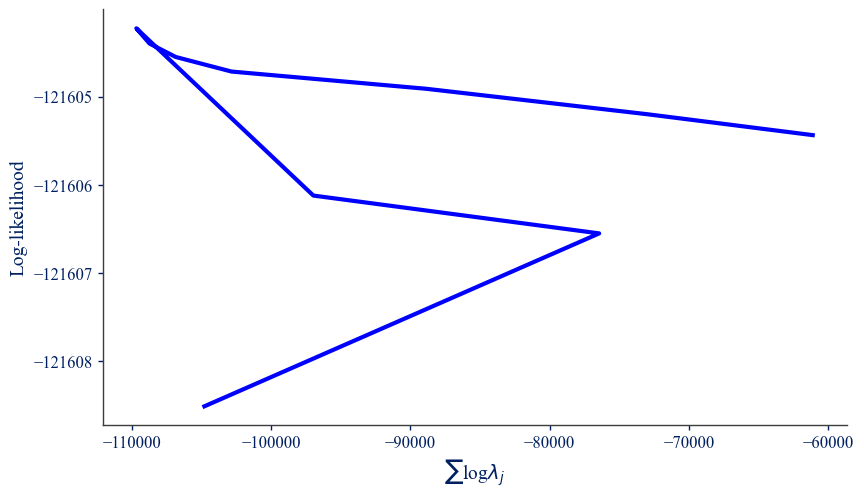

In [122]:
plt.plot(loglambda, logL)
plt.gca().ticklabel_format(useOffset=False)
plt.xlabel('$\sum$log$\lambda_j$')
plt.ylabel('Log-likelihood')
plt.show()

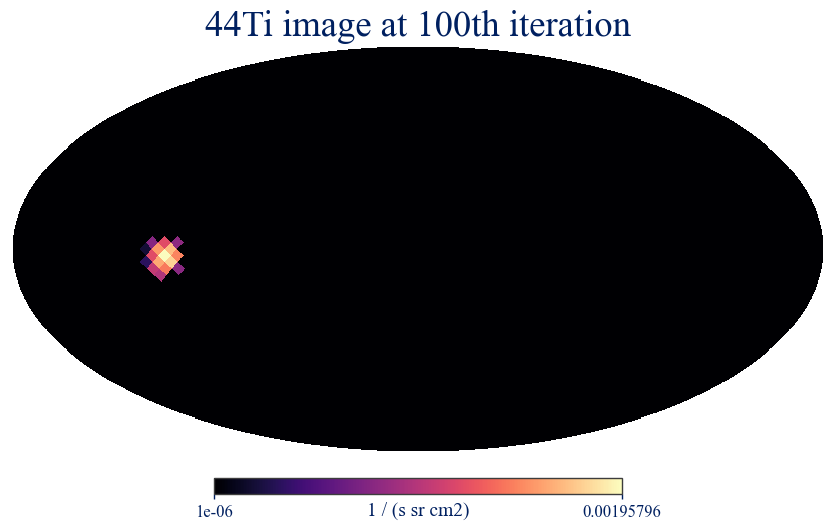

In [96]:
iteration_idx = 100

result = image_deconvolution.results[iteration_idx-1]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 0 * im.unit] = 1e-12 * im.unit

hp.mollview(im, min = 1e-6, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

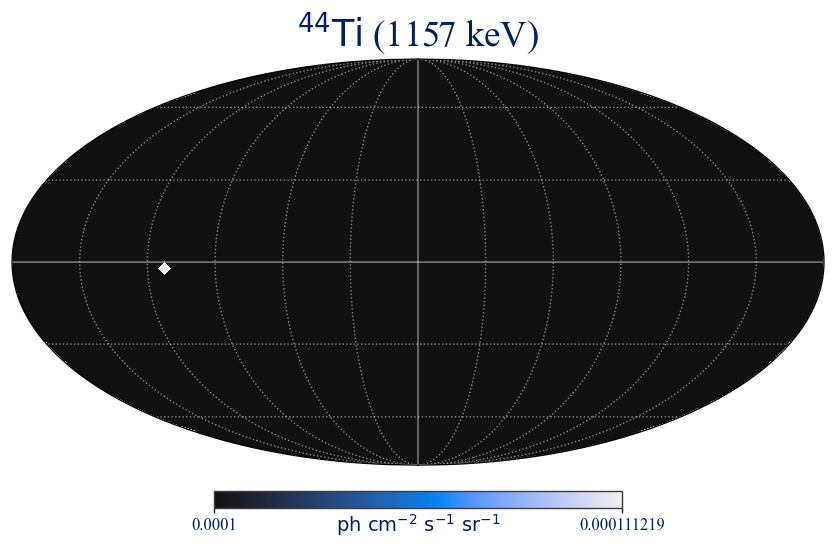

In [ ]:
import colorcet as cc
my_cmap = cc.cm.CET_CBL3
# Optional: ensure values below 'min' are also white
my_cmap.set_under('white')

hp.mollview(im, min=1e-4,norm ='log', unit = r"$\mathrm{ph \ cm^{-2} \ s^{-1} \ sr^{-1}}$", title = r"$^{44}\mathrm{Ti}$ (1157 keV)", cmap = cc.cm.CET_CBL3,bgcolor='white')
hp.graticule(dpar = 30, alpha = 0.5, color = 'white')
plt.show()

In [123]:
size = 9
np.sum(np.sort(im * 0.0041 * u.sr)[-size:])       # 0.0041 is the pixel area in steradians for nside = 16

<Quantity 2.14159688e-05 1 / (s cm2)>

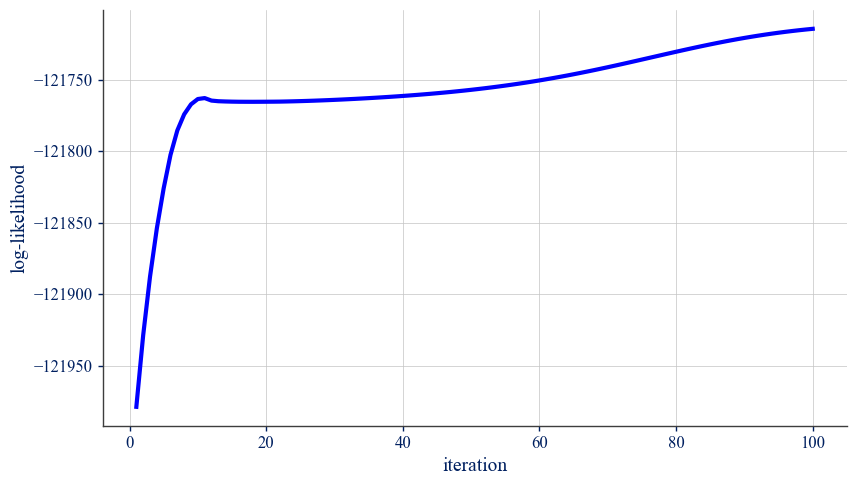

In [57]:
# Log-likelihood
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-likelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

In [45]:
# Acceleration parameter
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("accel_factor")
plt.show()

KeyError: 'alpha'

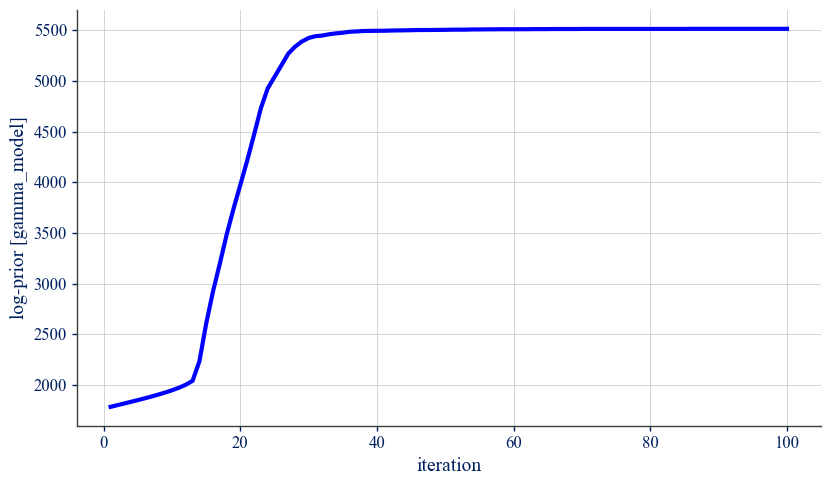

In [46]:
# Acceleration parameter
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-prior']['gamma_model'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-prior [gamma_model]")
plt.show()

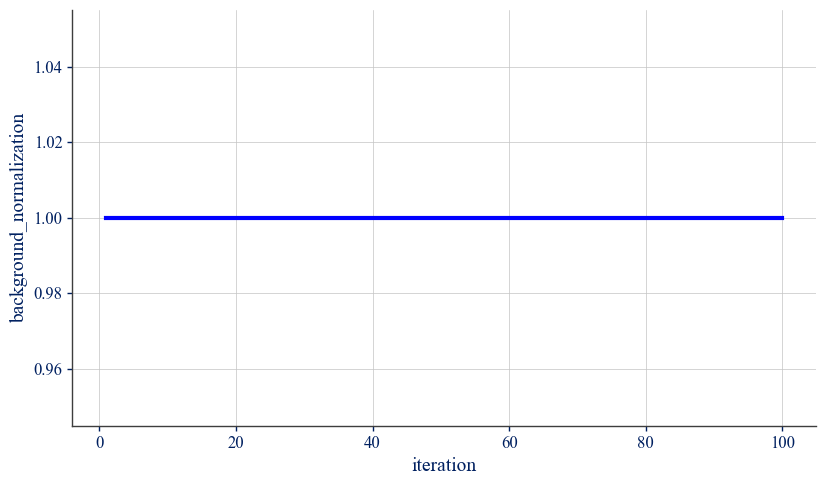

In [47]:
# Background Normalization
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['total'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

In [84]:
for iteration_idx in range(2, 201, 2):

    result = image_deconvolution.results[iteration_idx-1]

    iteration = result['iteration']
    image = result['model']

    im = image[:,0]
    im[im <= 0 * im.unit] = 1e-12 * im.unit

    hp.mollview(im, min = 1e-5, max = 1e-3, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

    plt.savefig(f'vanilla/{iteration_idx}.png')
    plt.close()

IndexError: list index out of range

In [7]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")
        plt.show()

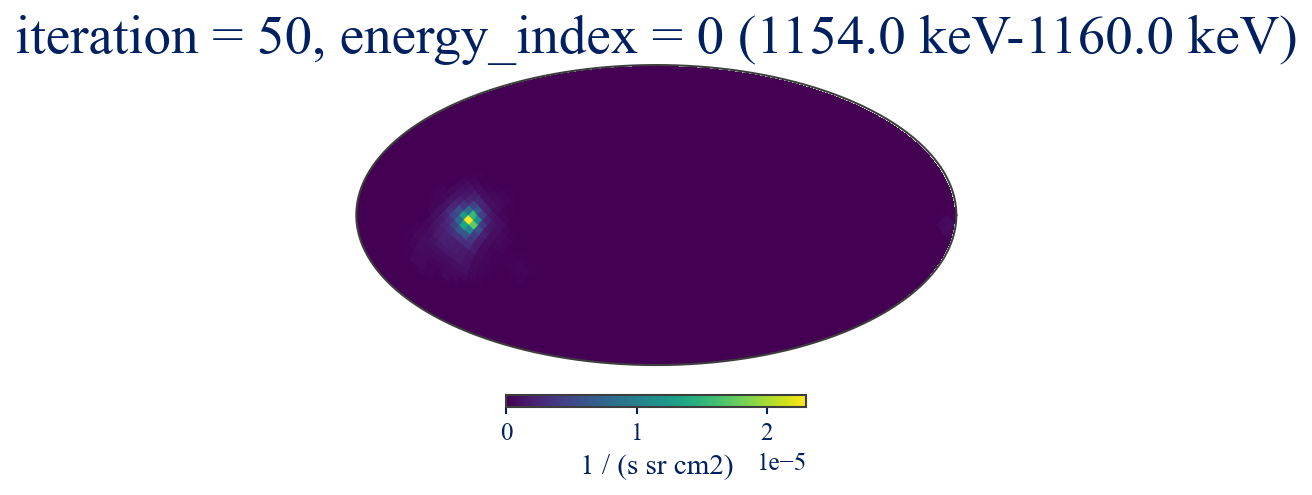

In [8]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

## TS Map

In [7]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi'), 
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


112.93372198951465
1359


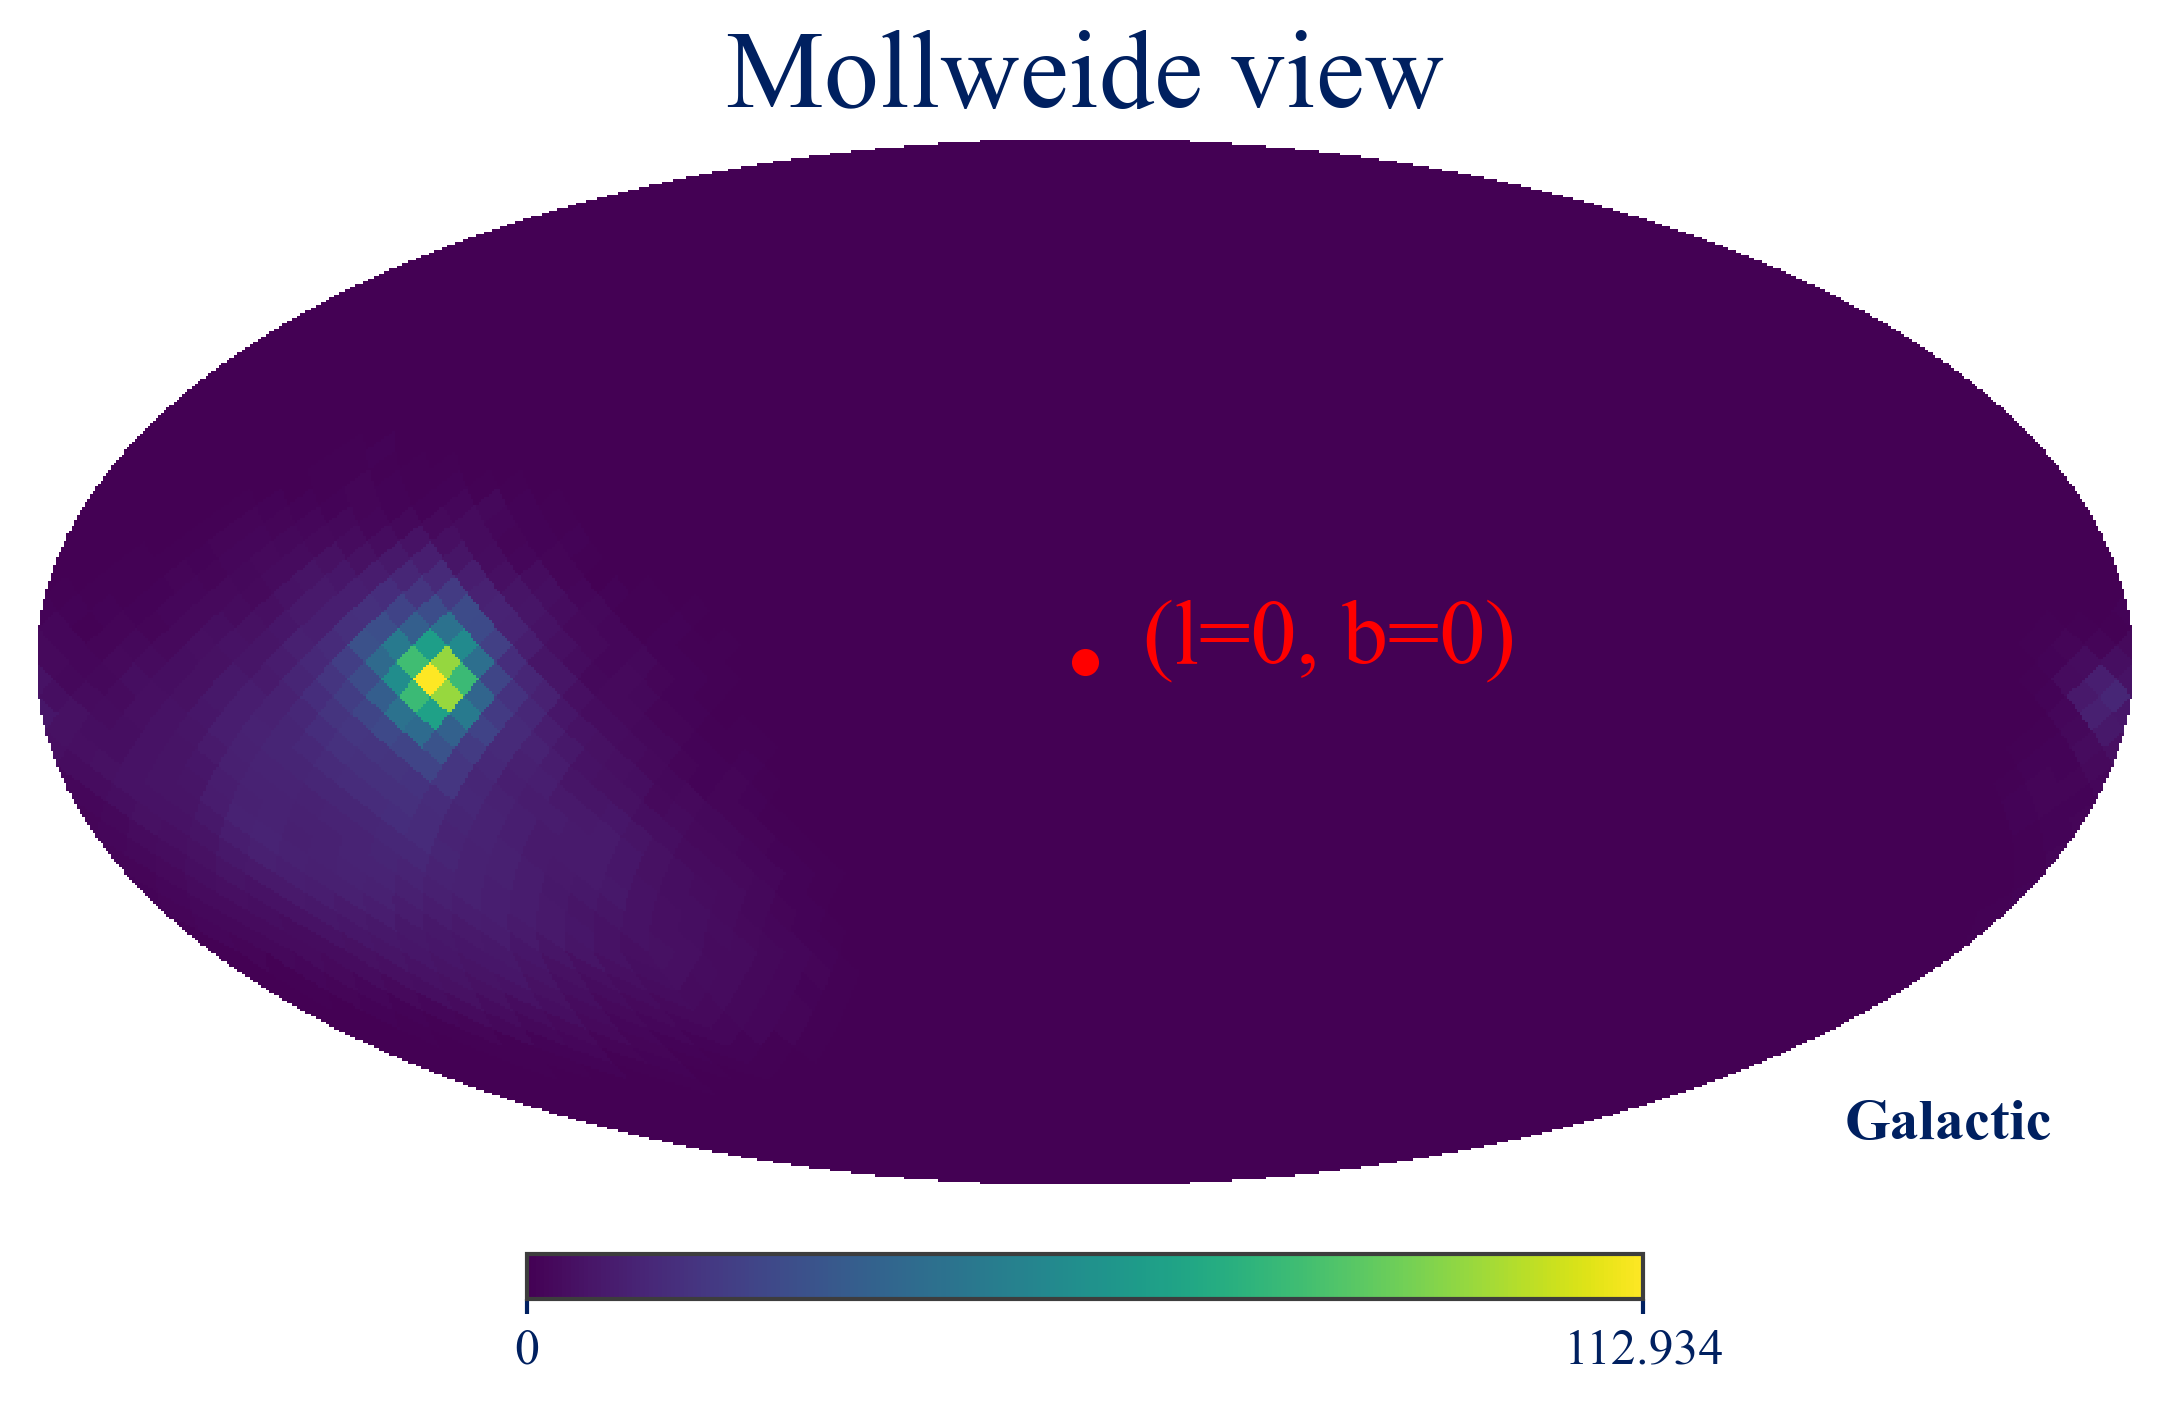

In [8]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

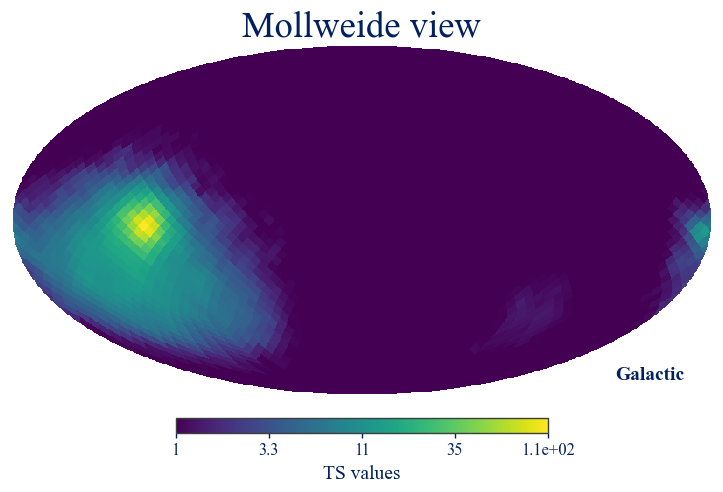

In [15]:
hp.mollview(ts_results+1, nest=True, coord = "G", hold = True, norm='log')
# hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "red")
# hp.projscatter(111.7, -2.1, marker = "o", lonlat=True, coord = "G", color = "red")
cbar = plt.gcf().axes[1]
cbar.set_xticks(np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5))
cbar.set_xticklabels([f'{x:.2g}' for x in np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5)])
cbar.set_xlabel('TS values')
plt.show()

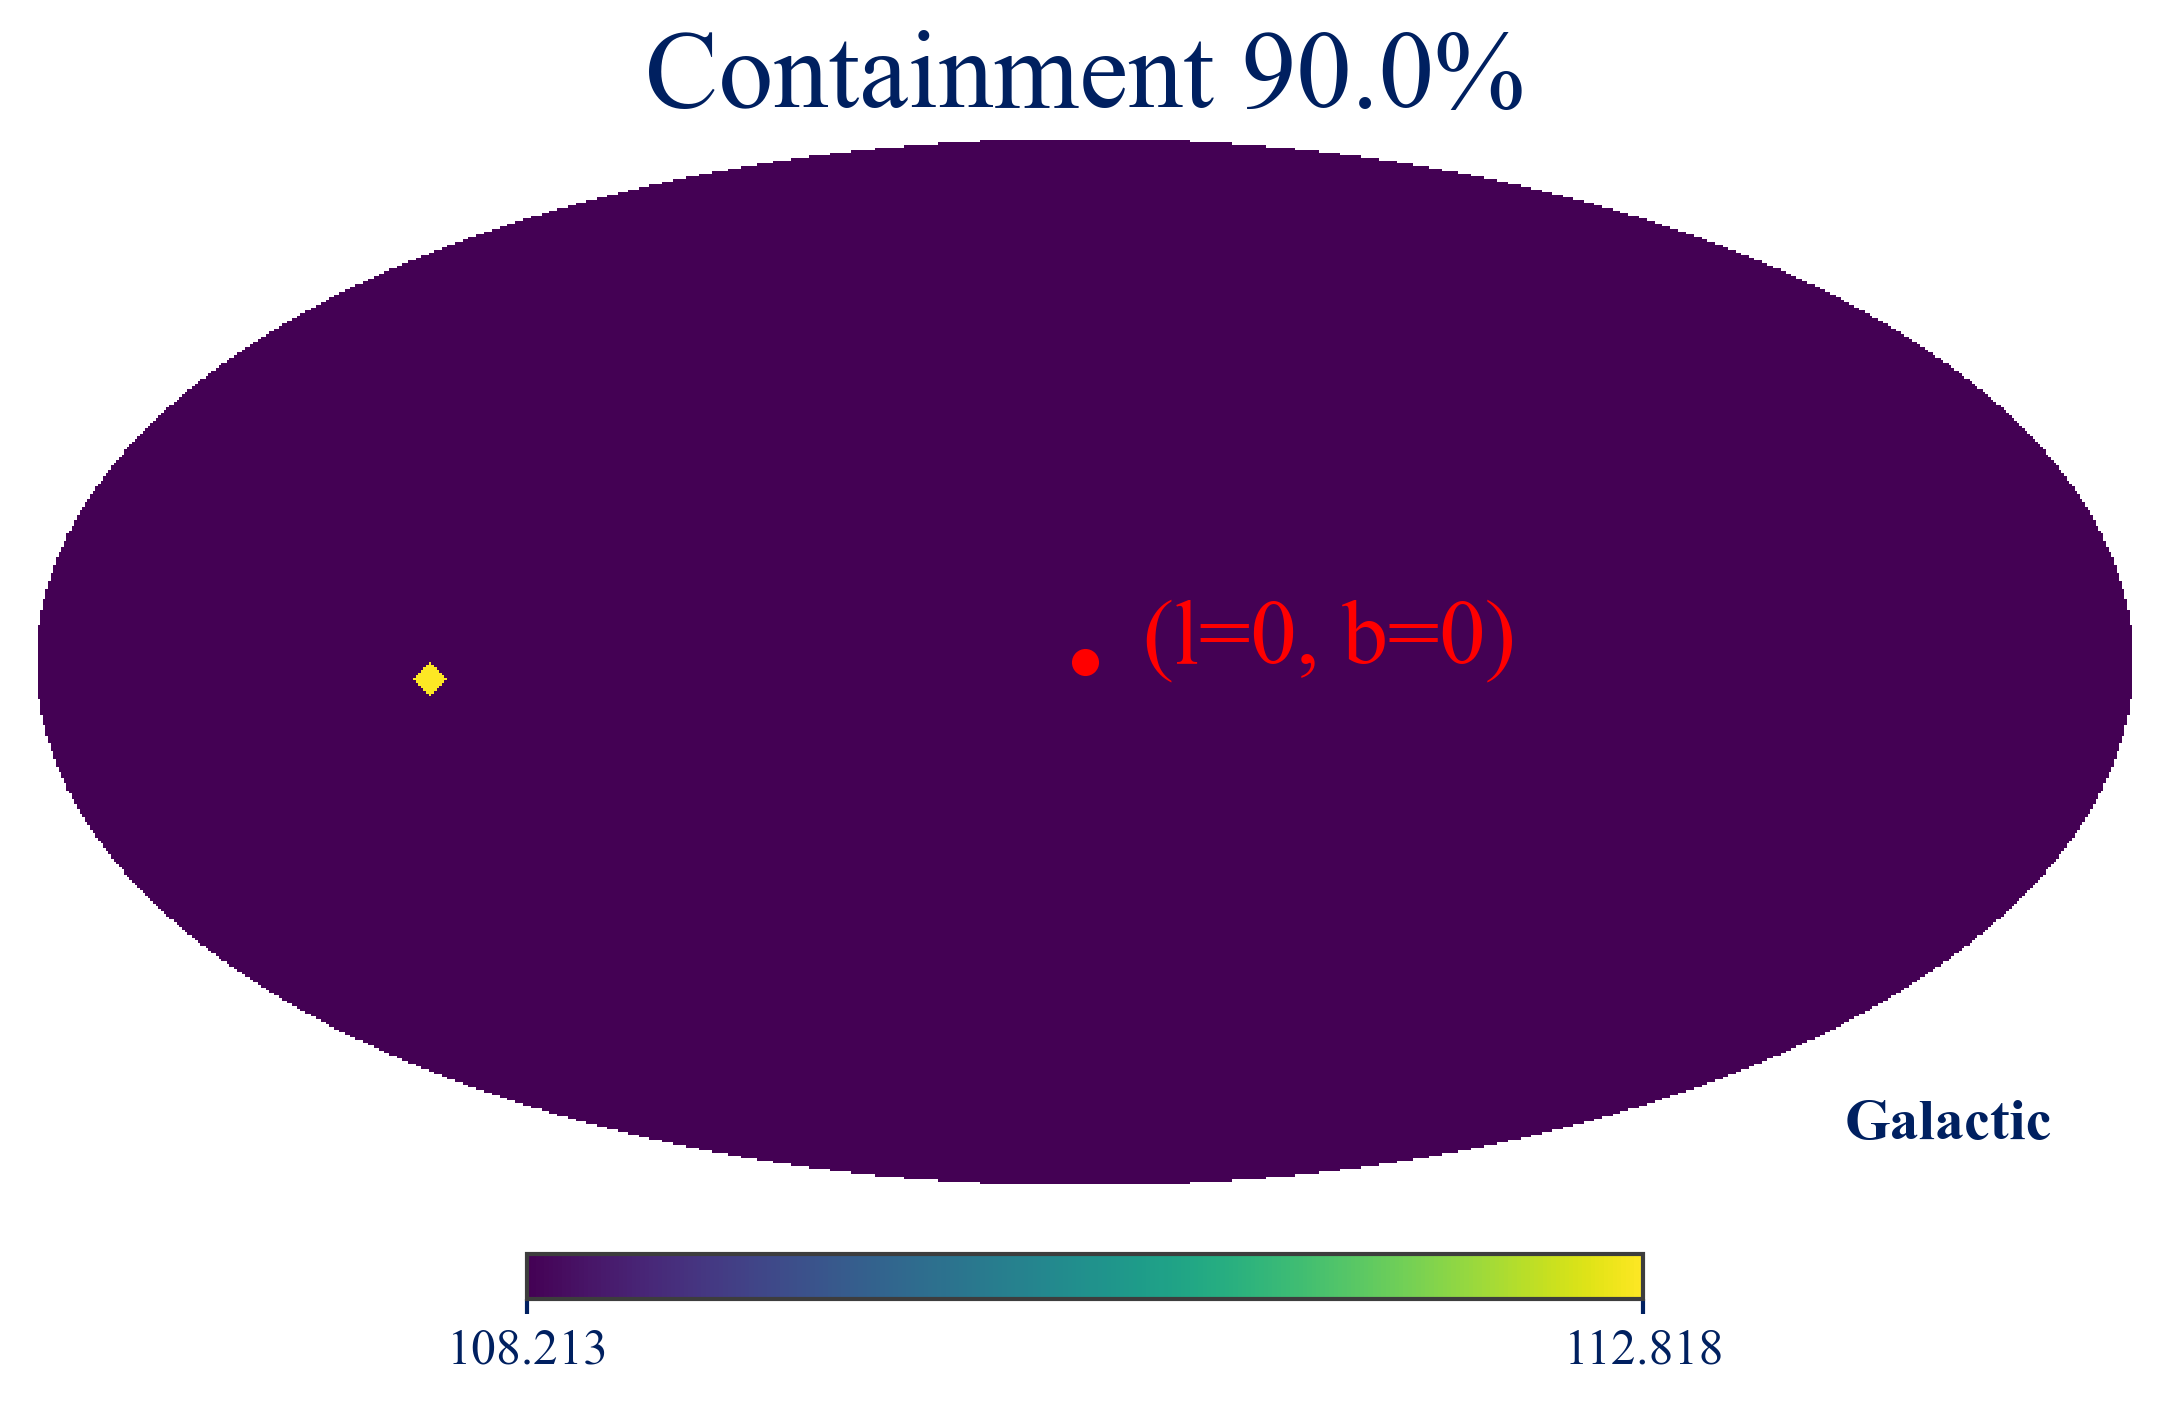

In [220]:
ts.plot_ts(ts_results, containment = 0.9)

## Crab and Cas A as background

### TS Map

In [12]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi') + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

In [85]:
inj1 = Histogram.open('../source_injector/unknown_src.h5')
inj2 = Histogram.open('../source_injector/OrEr.h5')
inj3 = Histogram.open('../source_injector/P3_low.h5')

In [64]:
ts = FastTSMap(
               data = data.project(['Em', 'Phi', 'PsiChi']) + inj1 + inj2, 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi') + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

1.539779039423422
2513


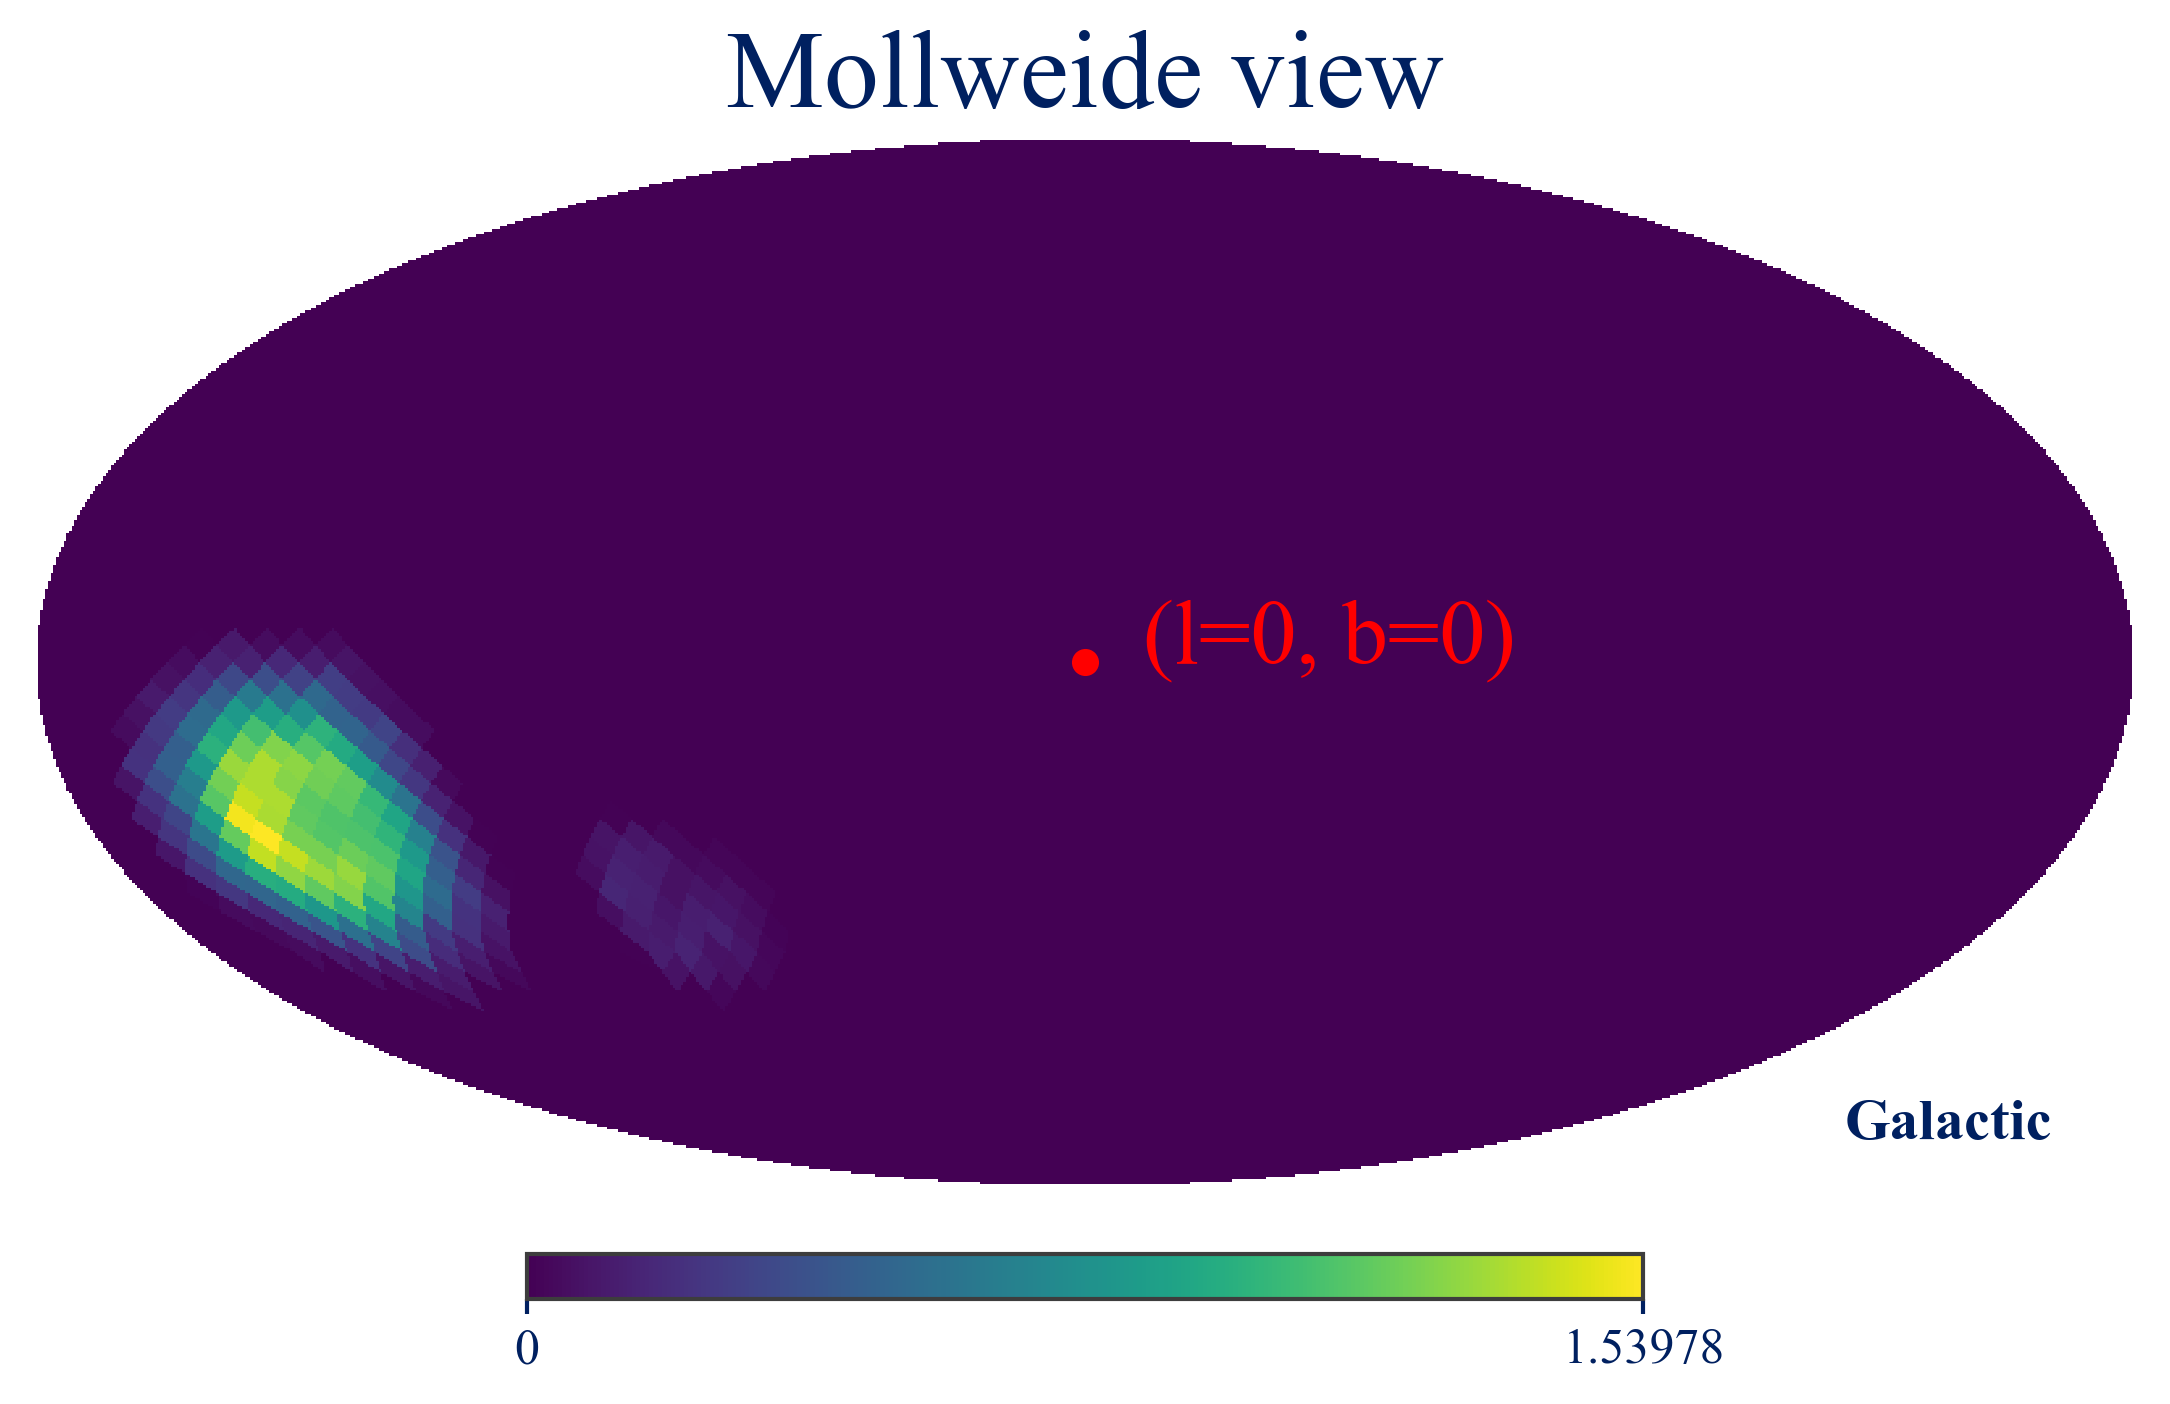

In [13]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

2606.866426486373
2513


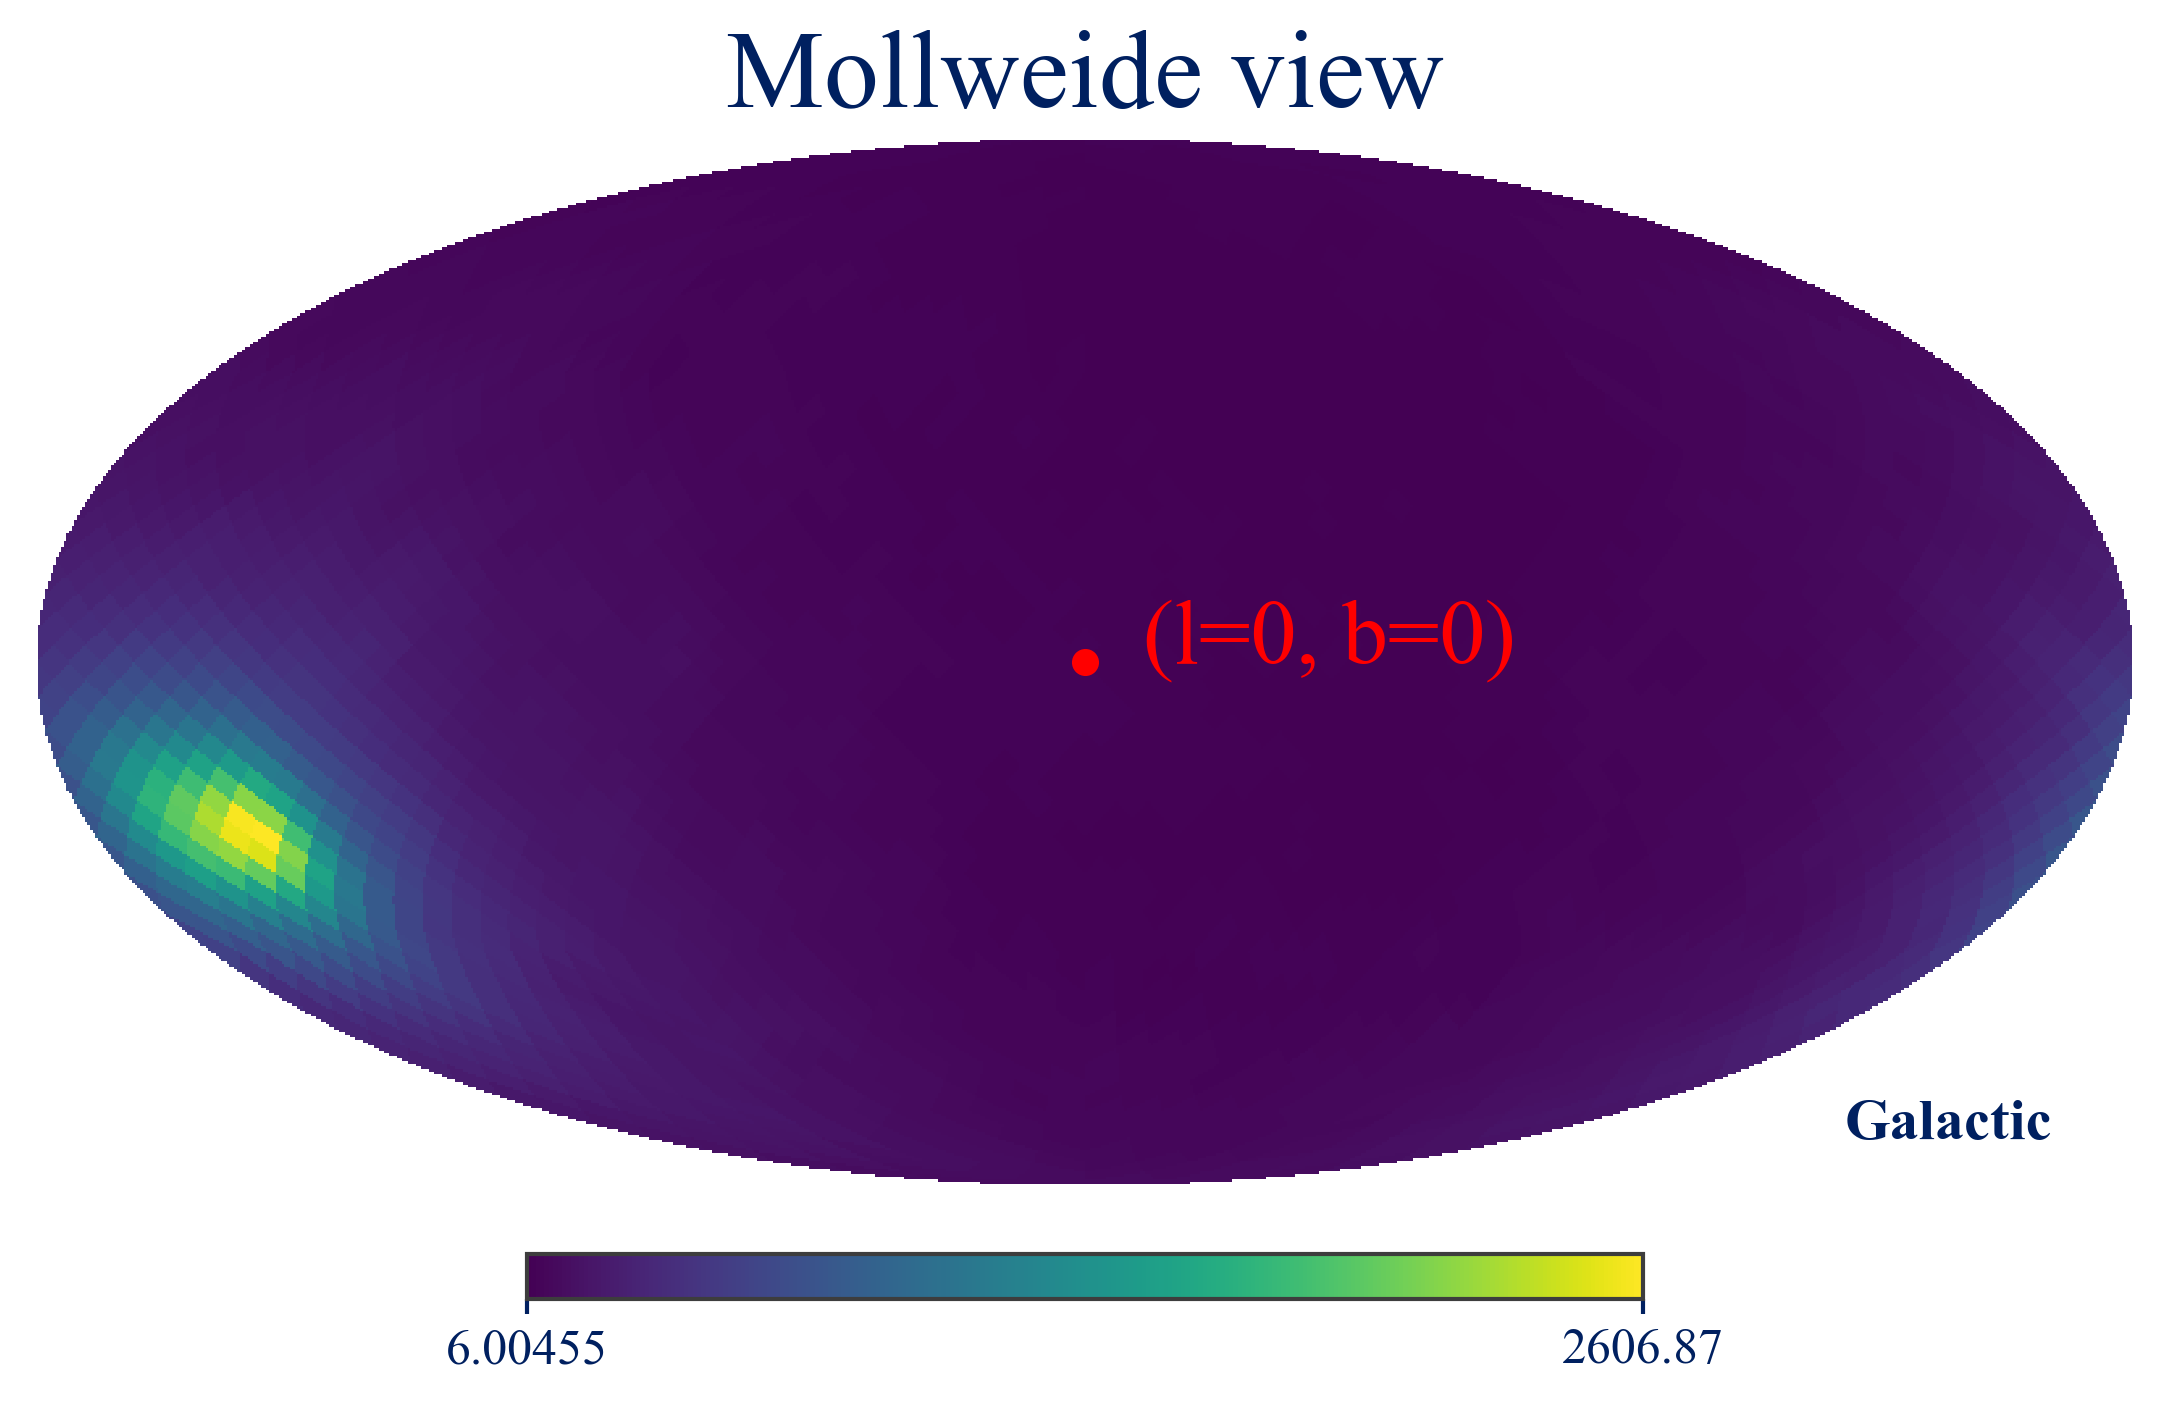

In [65]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [92]:
ts = FastTSMap(
               data = inj3, 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi')*0.08,
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

3971.792568676273
2135


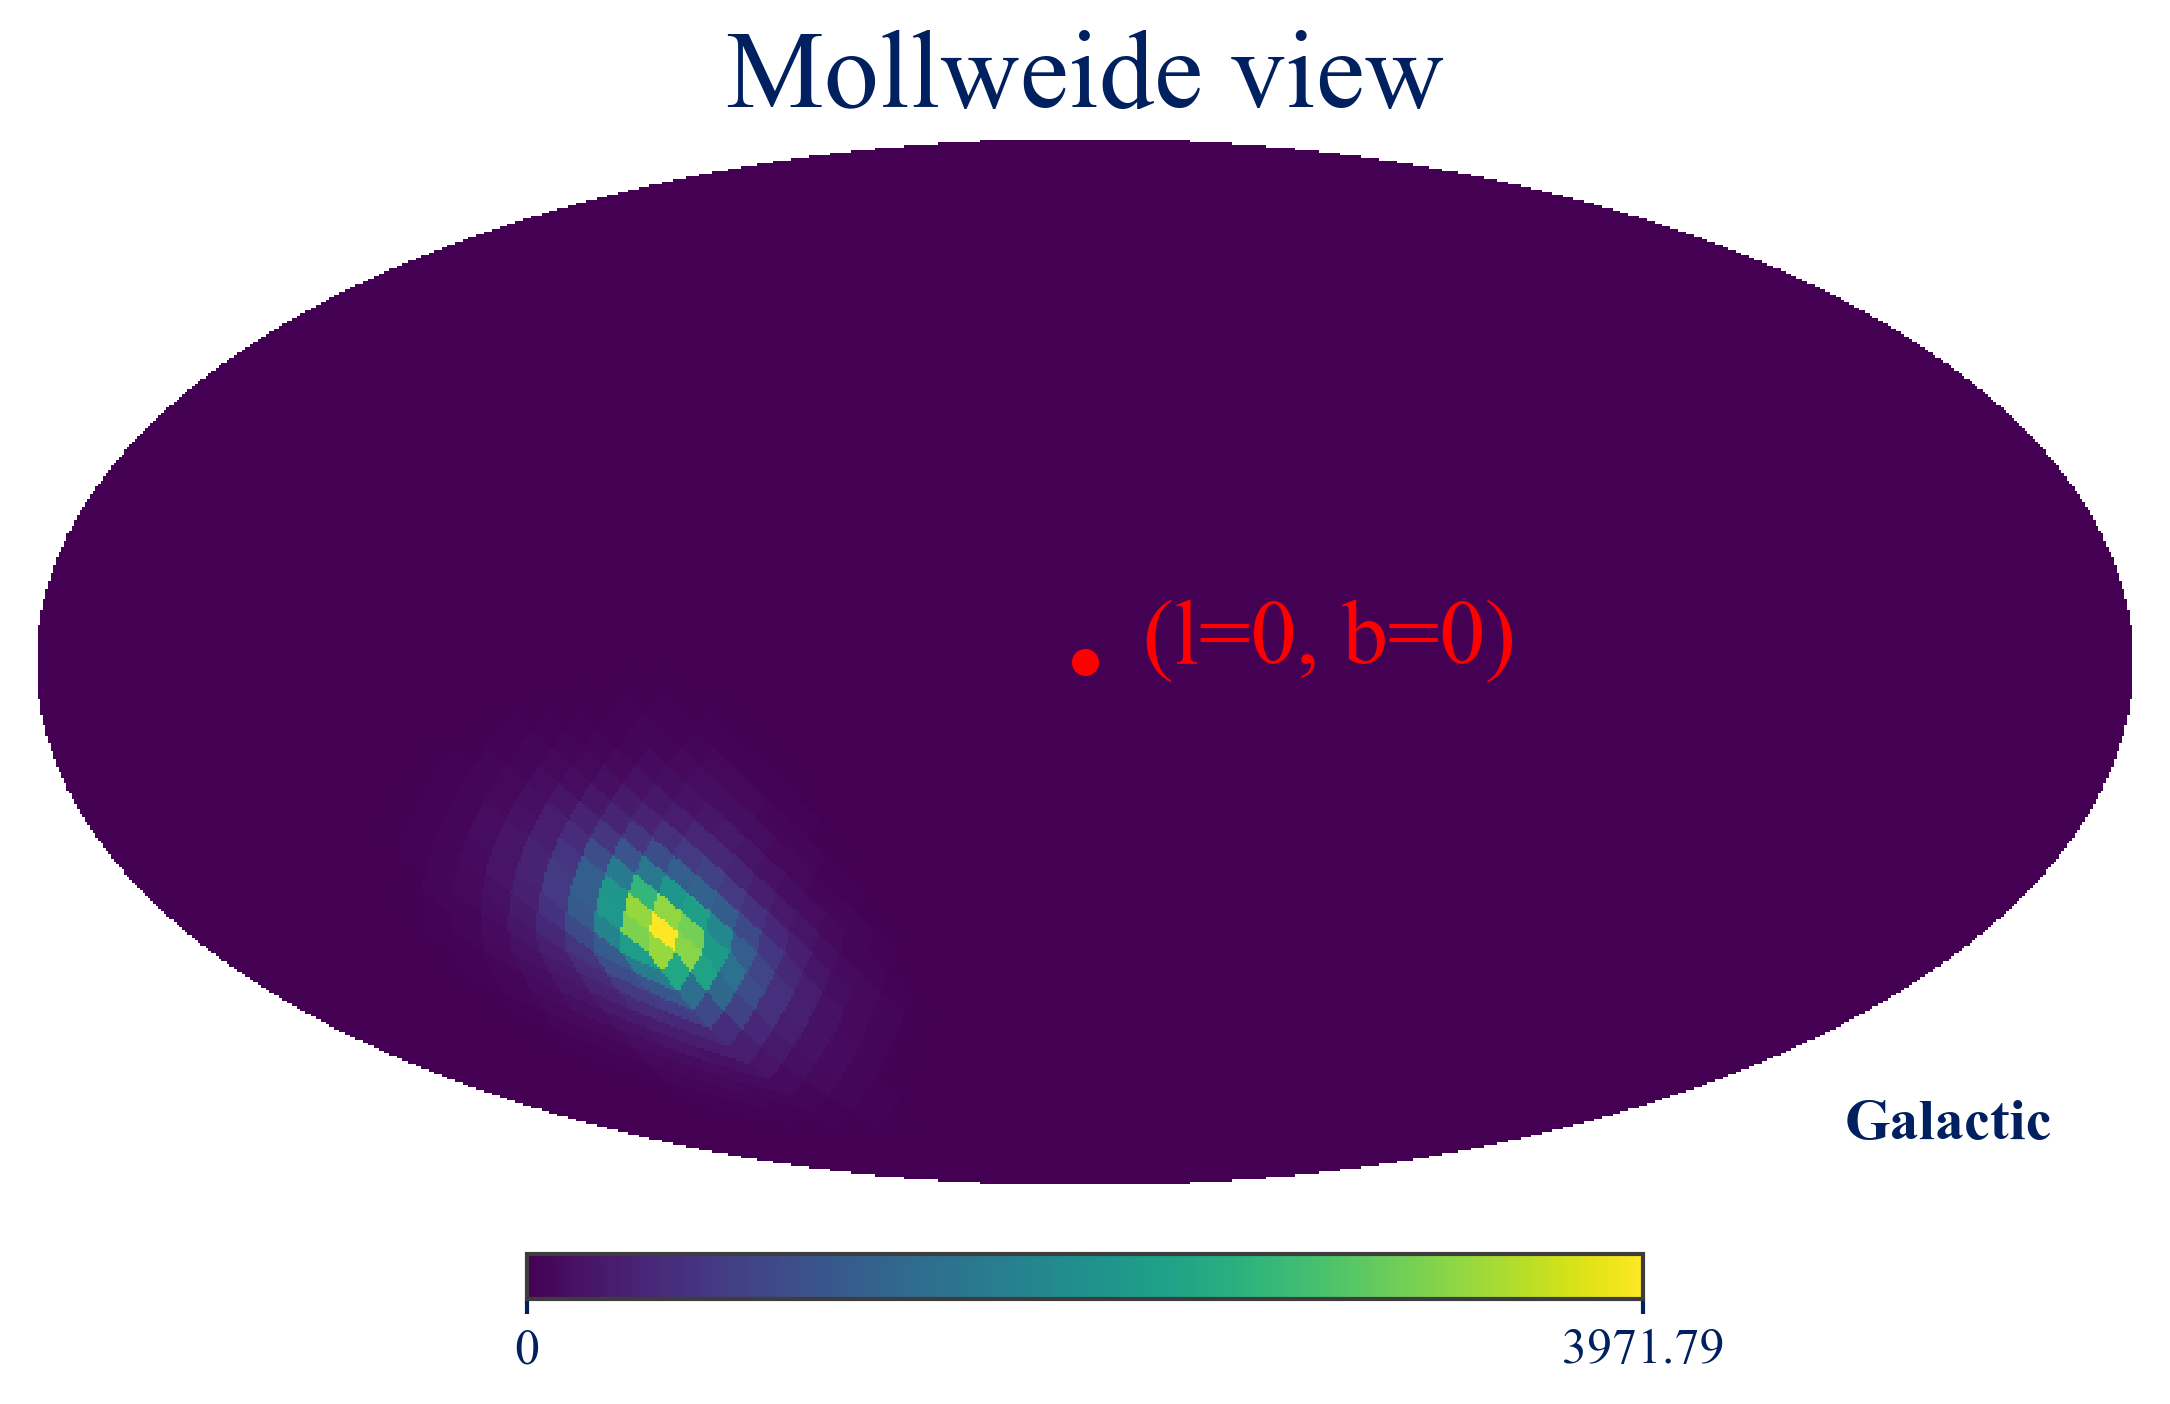

In [93]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

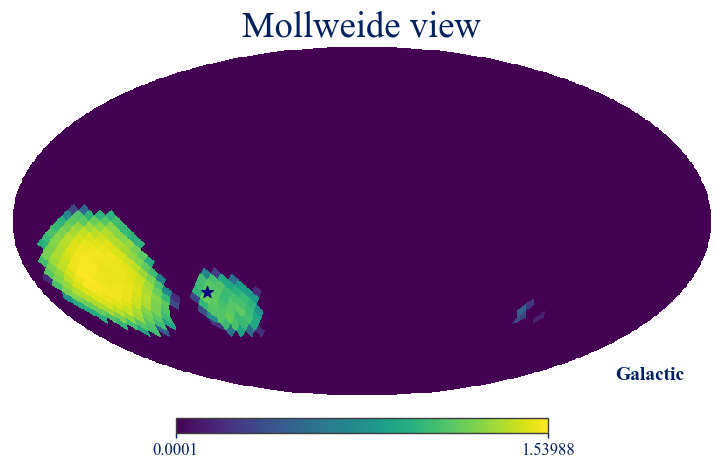

In [18]:
patch2 = hp.pix2ang(16, np.argsort(ts_results)[-132], True, True)
hp.mollview(ts_results+0.0001, nest=True, coord = "G", hold = True, norm='log')
hp.projscatter(*patch2, marker = "*", s=75, lonlat=True, coord = "G", color = "navy")
plt.show()

In [51]:
hp.pix2ang(16, 2516, nest=True, lonlat=True)

(151.875, -22.02431283704216)

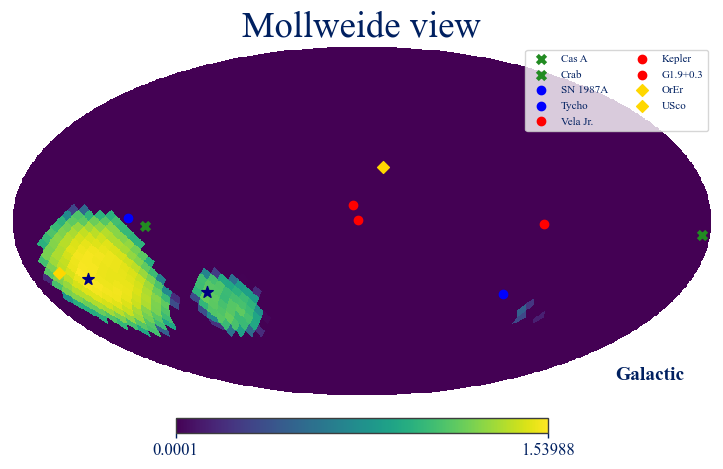

In [178]:
hp.mollview(ts_results+0.0001, nest=True, coord = "G", hold = True, norm='log')
hp.projscatter(111.7, -2.1, marker = "x", lonlat=True, coord = "G", color = "forestgreen", label='Cas A')
hp.projscatter(184.56, -5.78, marker = "x", lonlat=True, coord = "G", color = "forestgreen", label='Crab')
hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "blue", label='SN 1987A')
hp.projscatter(120.1,  1.4, marker = "o", lonlat=True, coord = "G", color = "blue", label='Tycho')
hp.projscatter(266.3, -1.21, marker = "o", lonlat=True, coord = "G", color = "red", label='Vela Jr.')
hp.projscatter(4.5, 6.8, marker = "o", lonlat=True, coord = "G", color = "red", label='Kepler')
hp.projscatter(1.9, 0.3, marker = "o", lonlat=True, coord = "G", color = "red", label='G1.9+0.3')
hp.projscatter(163, -22, marker = "D", lonlat=True, coord = "G", color = "gold", label='OrEr')
hp.projscatter(348.5, 22.5, marker = "D", lonlat=True, coord = "G", color = "gold", label='USco')

patch1 = hp.pix2ang(16, np.argmax(ts_results), True, True)
hp.projscatter(*patch1, marker = "*", s=75, lonlat=True, coord = "G", color = "navy")

patch2 = hp.pix2ang(16, np.argsort(ts_results)[-132], True, True)
hp.projscatter(*patch2, marker = "*", s=75, lonlat=True, coord = "G", color = "navy")

plt.legend(ncols=2)
plt.show()

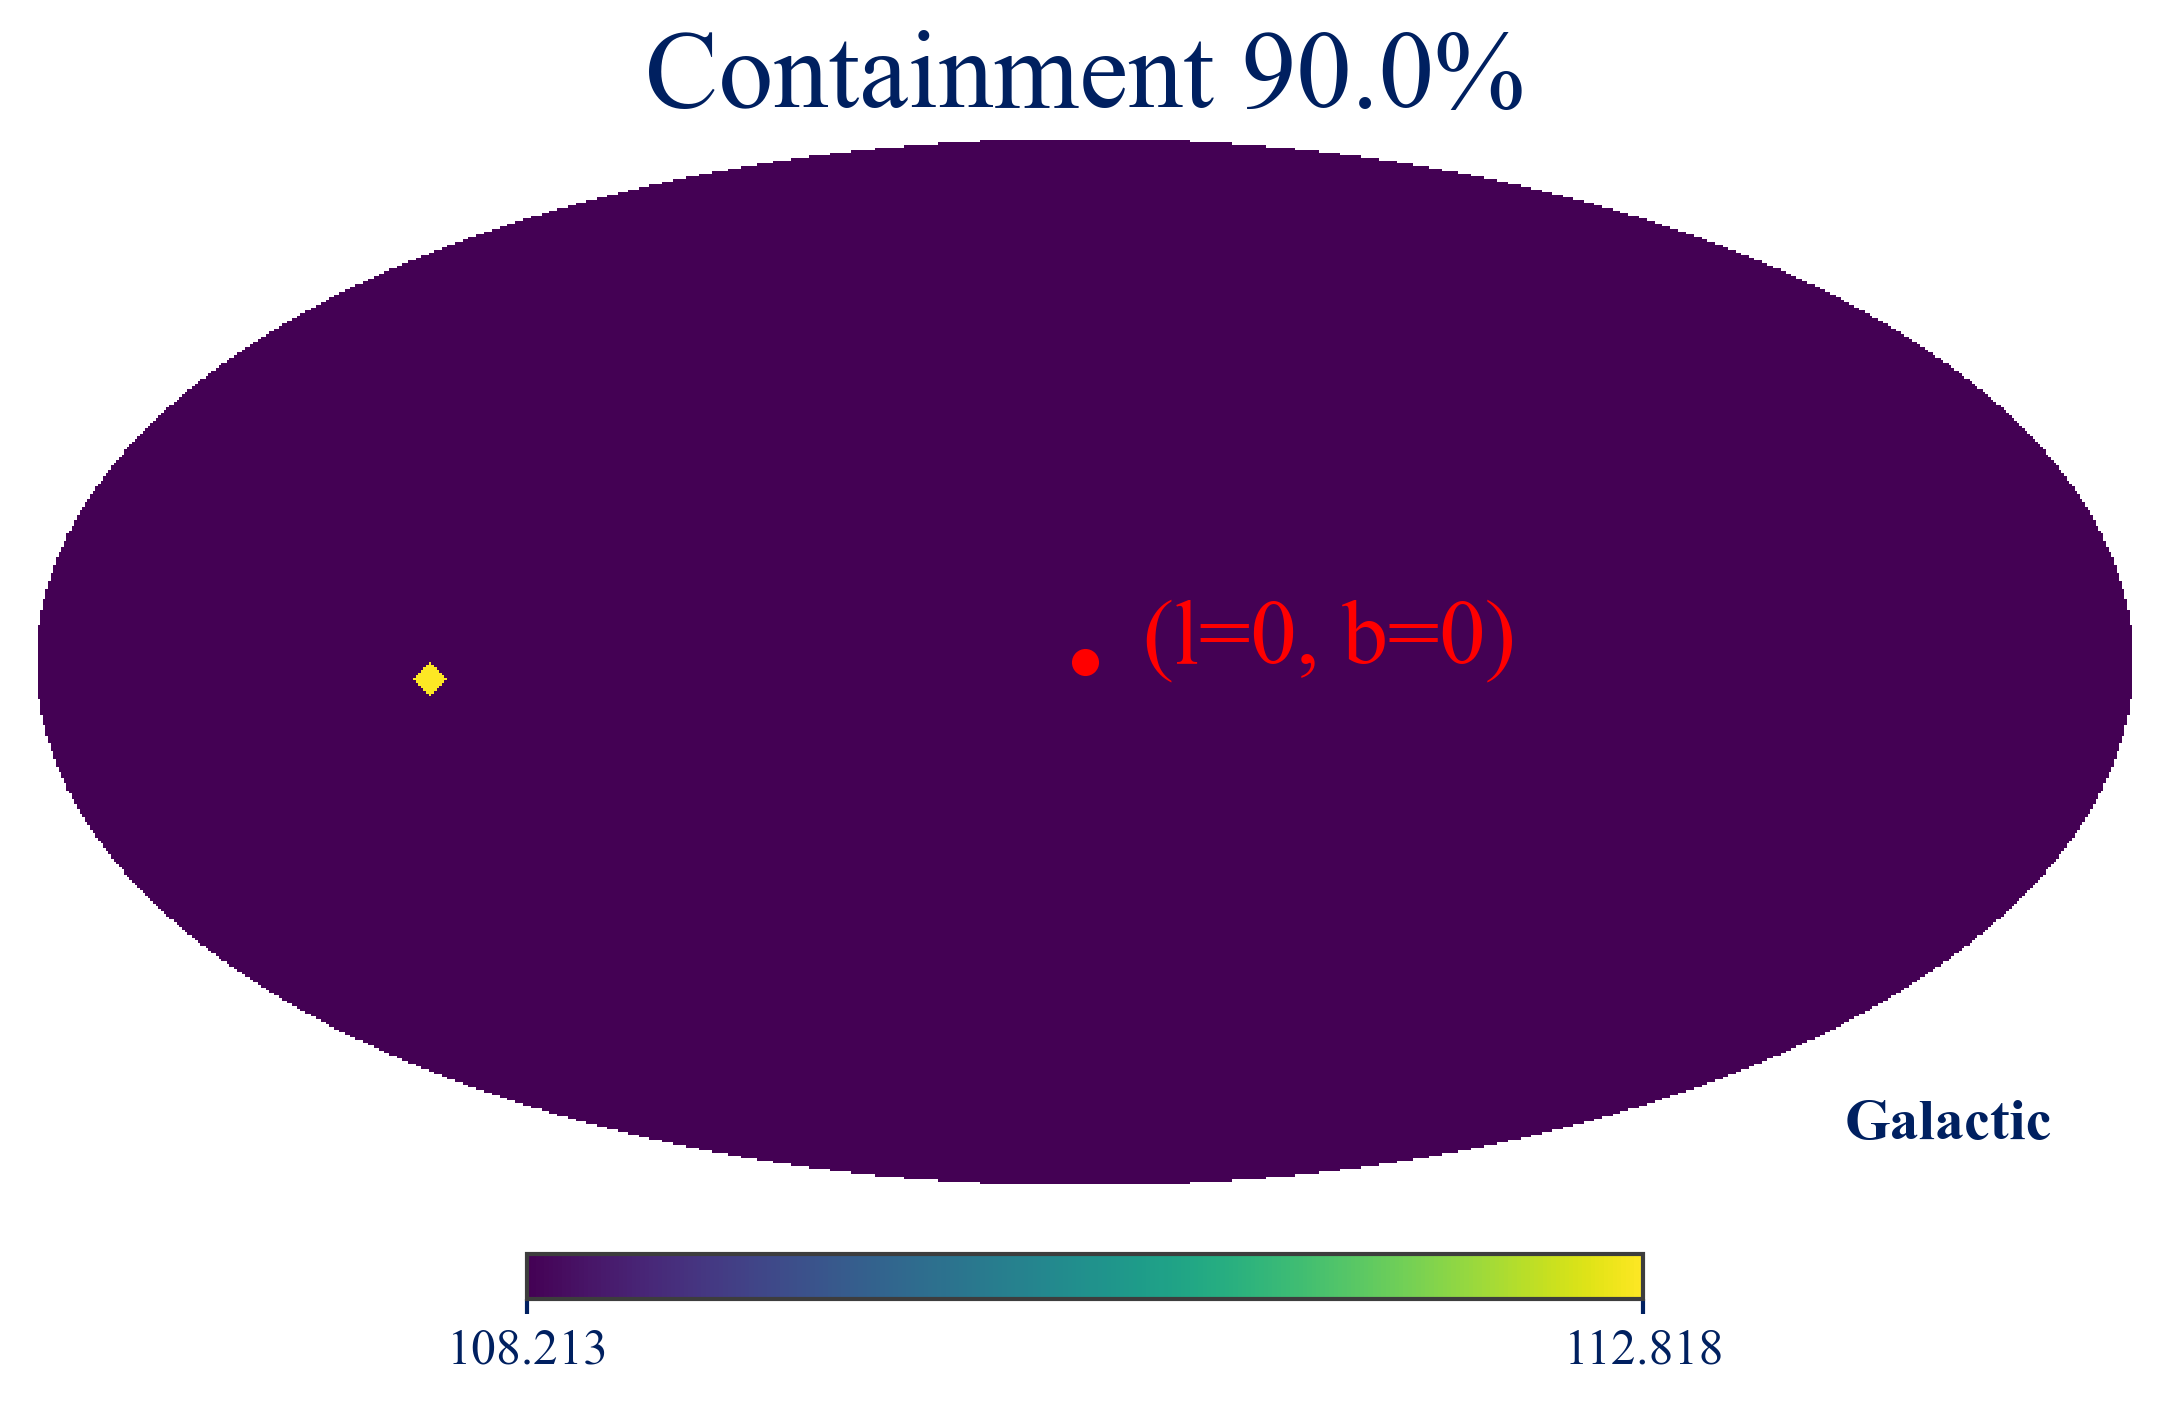

In [ ]:
ts.plot_ts(ts_results, containment = 0.9)

### Image Deconvolution

In [7]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi']),
                                                              'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                              'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [9]:
model_inj = Histogram.open('../source_injector/P3_low.h5')

In [10]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']) + model_inj,
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi']),
                                                              'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                              'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [11]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

: 

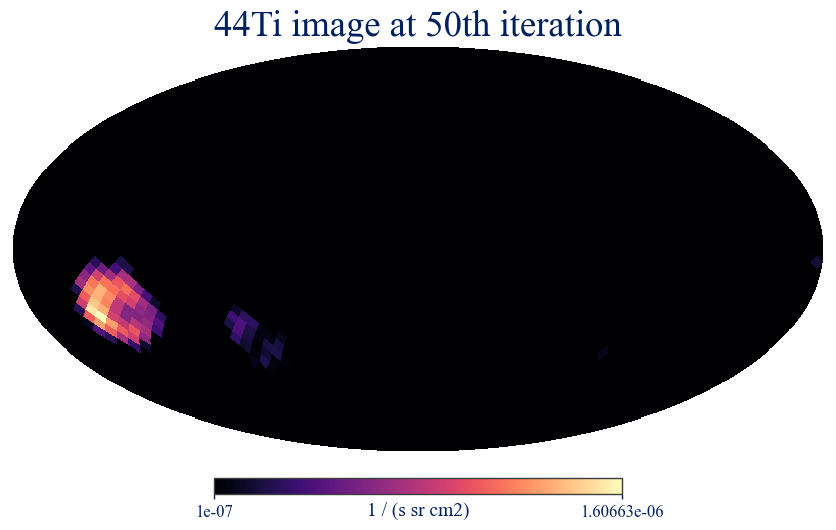

In [10]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 1e-10 * im.unit] = 1e-10 * im.unit

hp.mollview(im, min = 1e-7, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

## Applying poisson fluctuations to background

### Sanity Checks

In [342]:
baby = bg.project(['Em', 'Phi', 'PsiChi']).todense().contents
np.random.poisson(baby.flatten()[np.where(baby.flatten() > 5)[0]])

array([4, 7, 3, 6, 9, 5, 4, 8, 3, 4, 4, 2, 3, 5, 1, 8, 7])

In [367]:
l = []
for i in range(5000):
    l.append(np.random.poisson(baby).sum() - baby.sum())

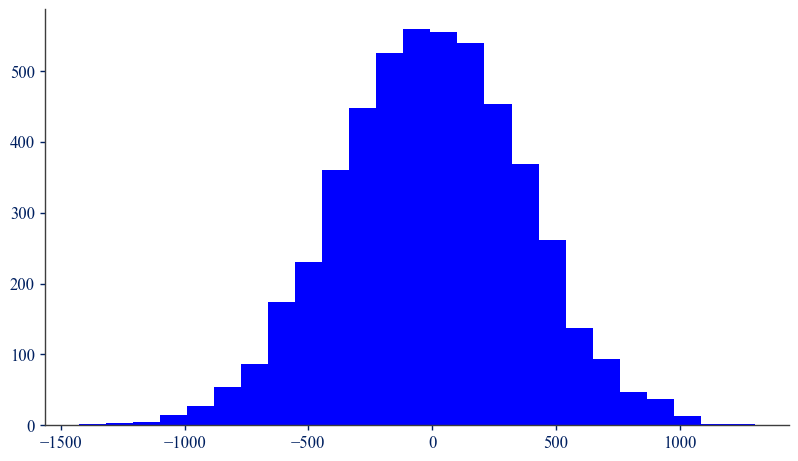

In [368]:
plt.hist(l)
plt.show()

### Image Deconvolution

In [16]:
hist = bg.project(['Em', 'Phi', 'PsiChi']).todense()

new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(axis.edges, label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

new_bg = Histogram(new_axes,
                           contents = np.random.poisson(hist.contents),
                           sparse=hist.is_sparse,
                           unit=hist.unit)

In [ ]:
# new_bg = deepcopy(bg)
# new_bg = np.random.poisson(bg.project(['Em', 'Phi', 'PsiChi']).todense().contents)

In [12]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": new_bg,},
                                                            #   'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                            #   'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [ ]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.override_parameter("deconvolution:parameter_RL:iteration = 200")
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

: 

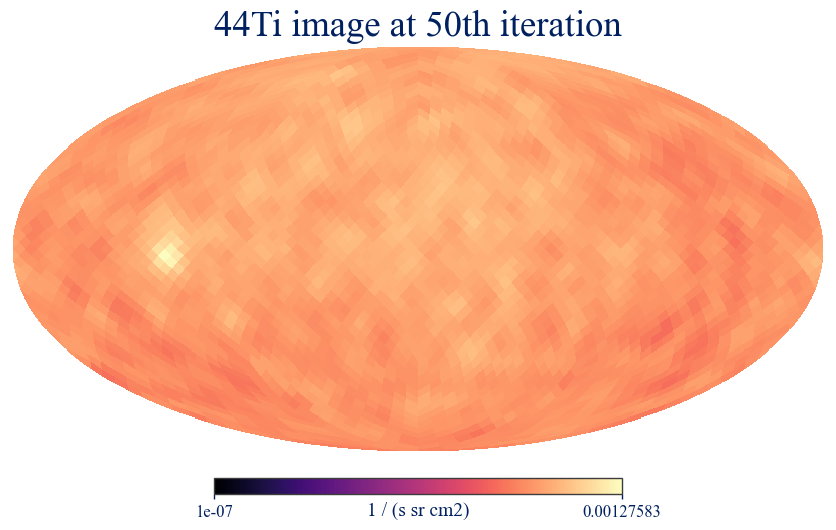

In [14]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 0 * im.unit] = 1e-12 * im.unit

hp.mollview(im, min = 1e-7, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

**WHY IS THE BACKGROUND NORMALIZATION ALWAYS FALLING TO 0.28 FROM 1.04**

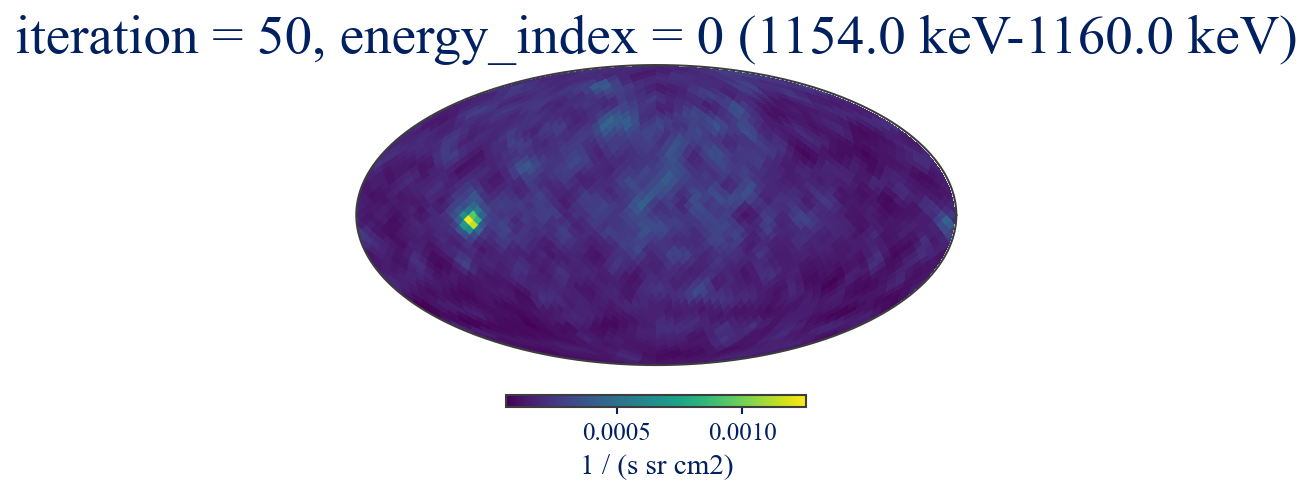

In [410]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

### TS Map

In [17]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.28*new_bg + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

4216.143793390216
1108


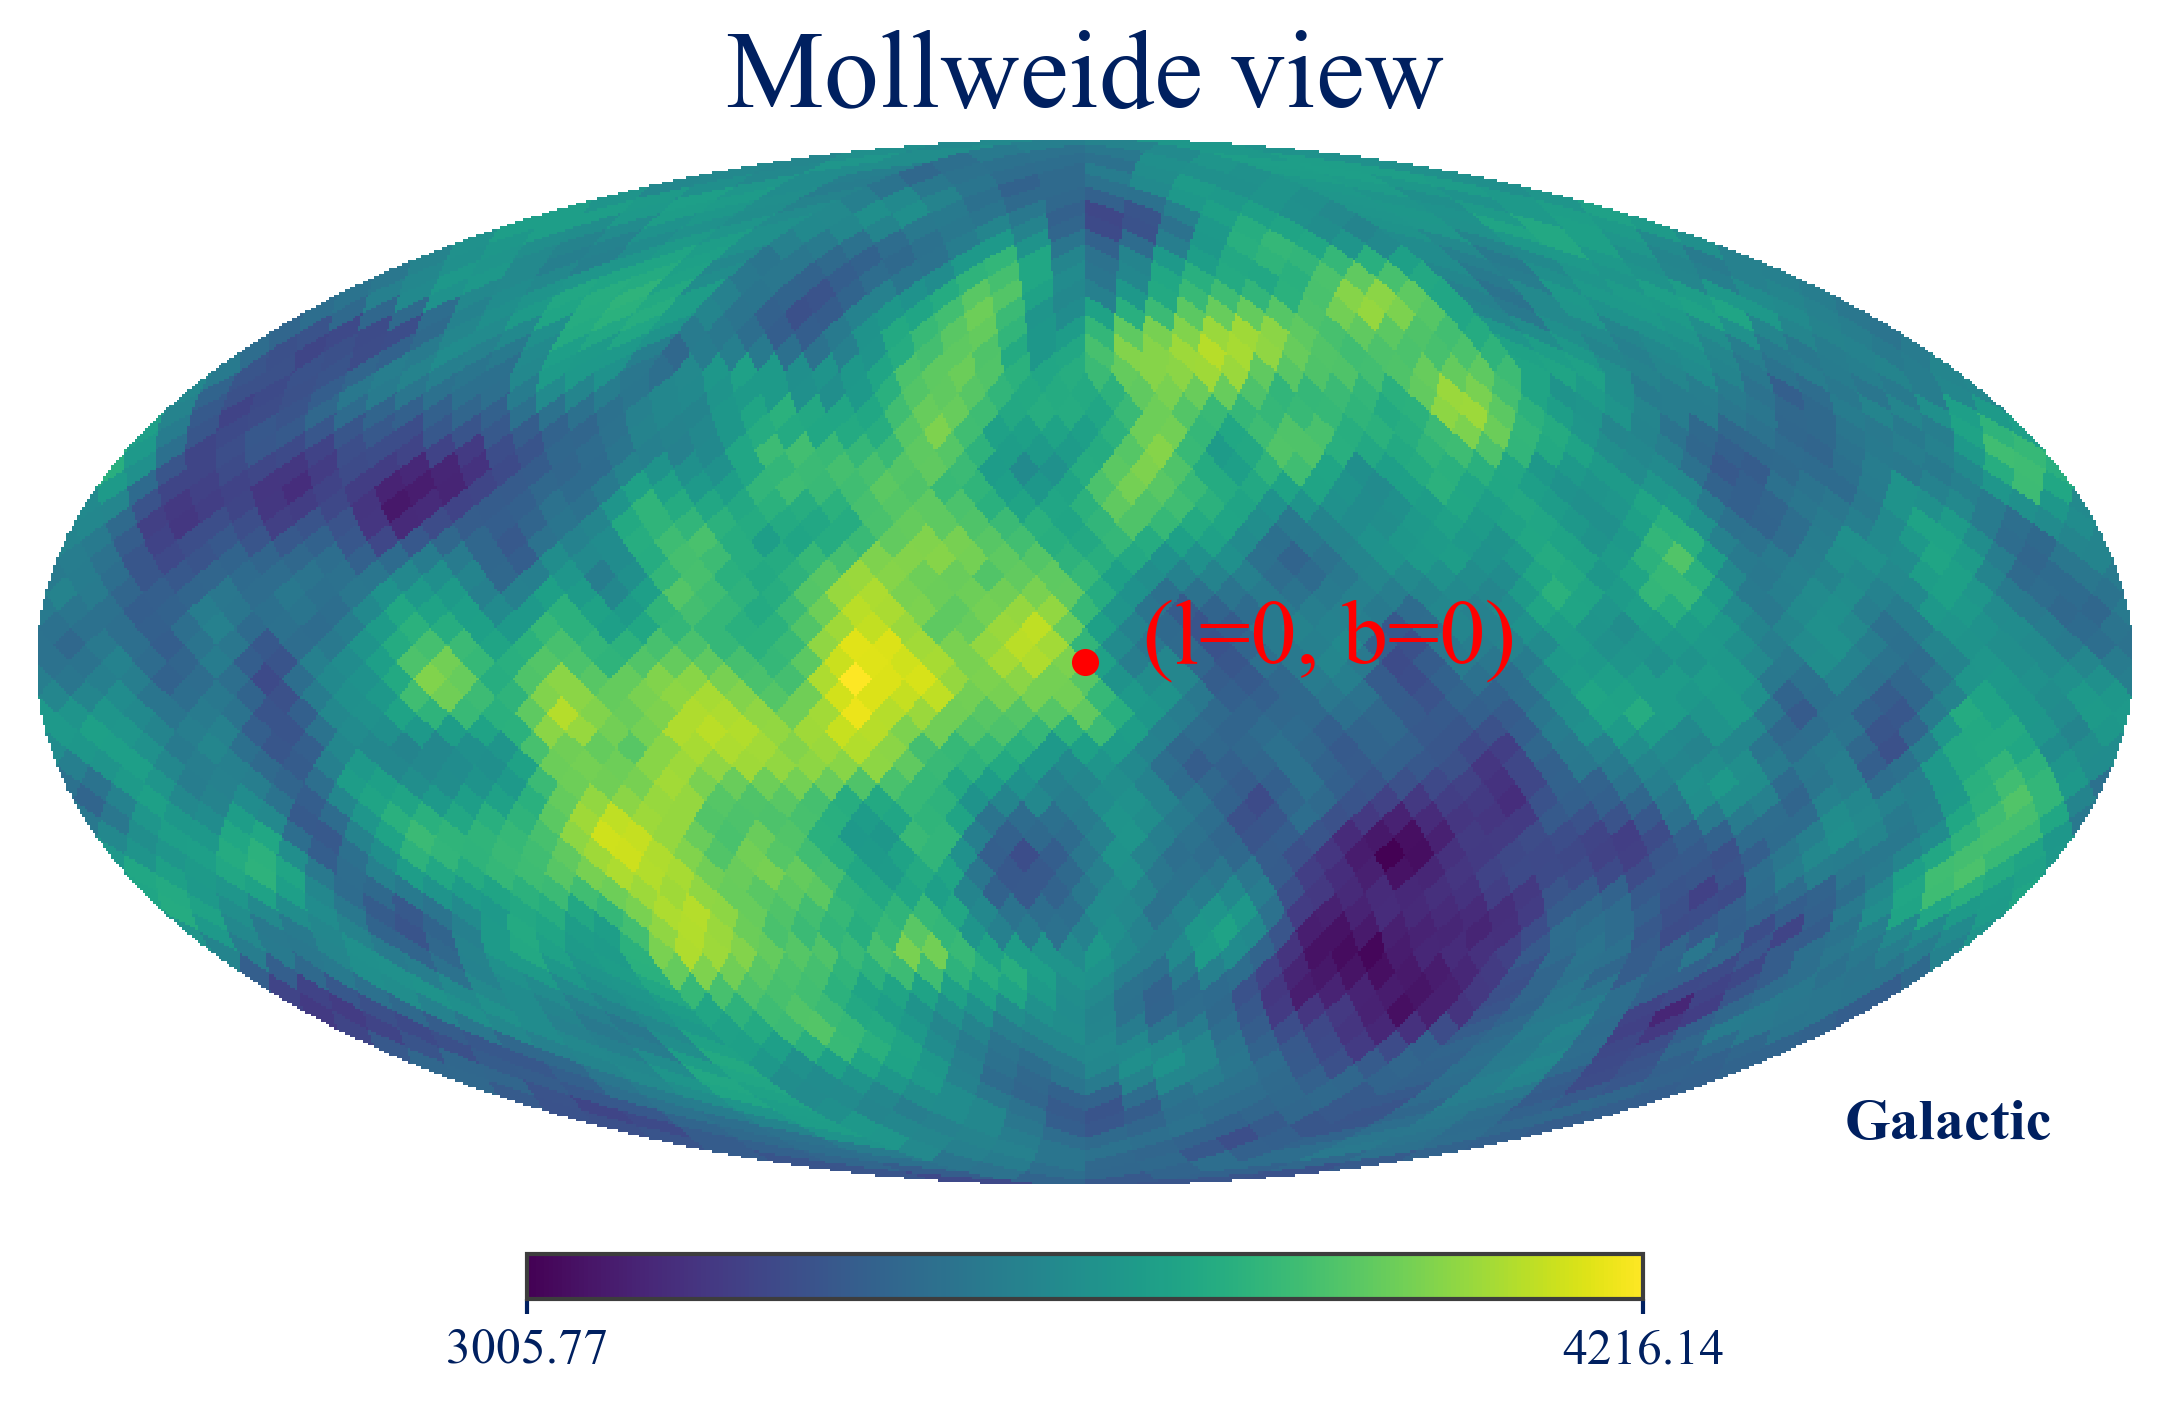

In [18]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.28*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

5161.5199089618545
1359


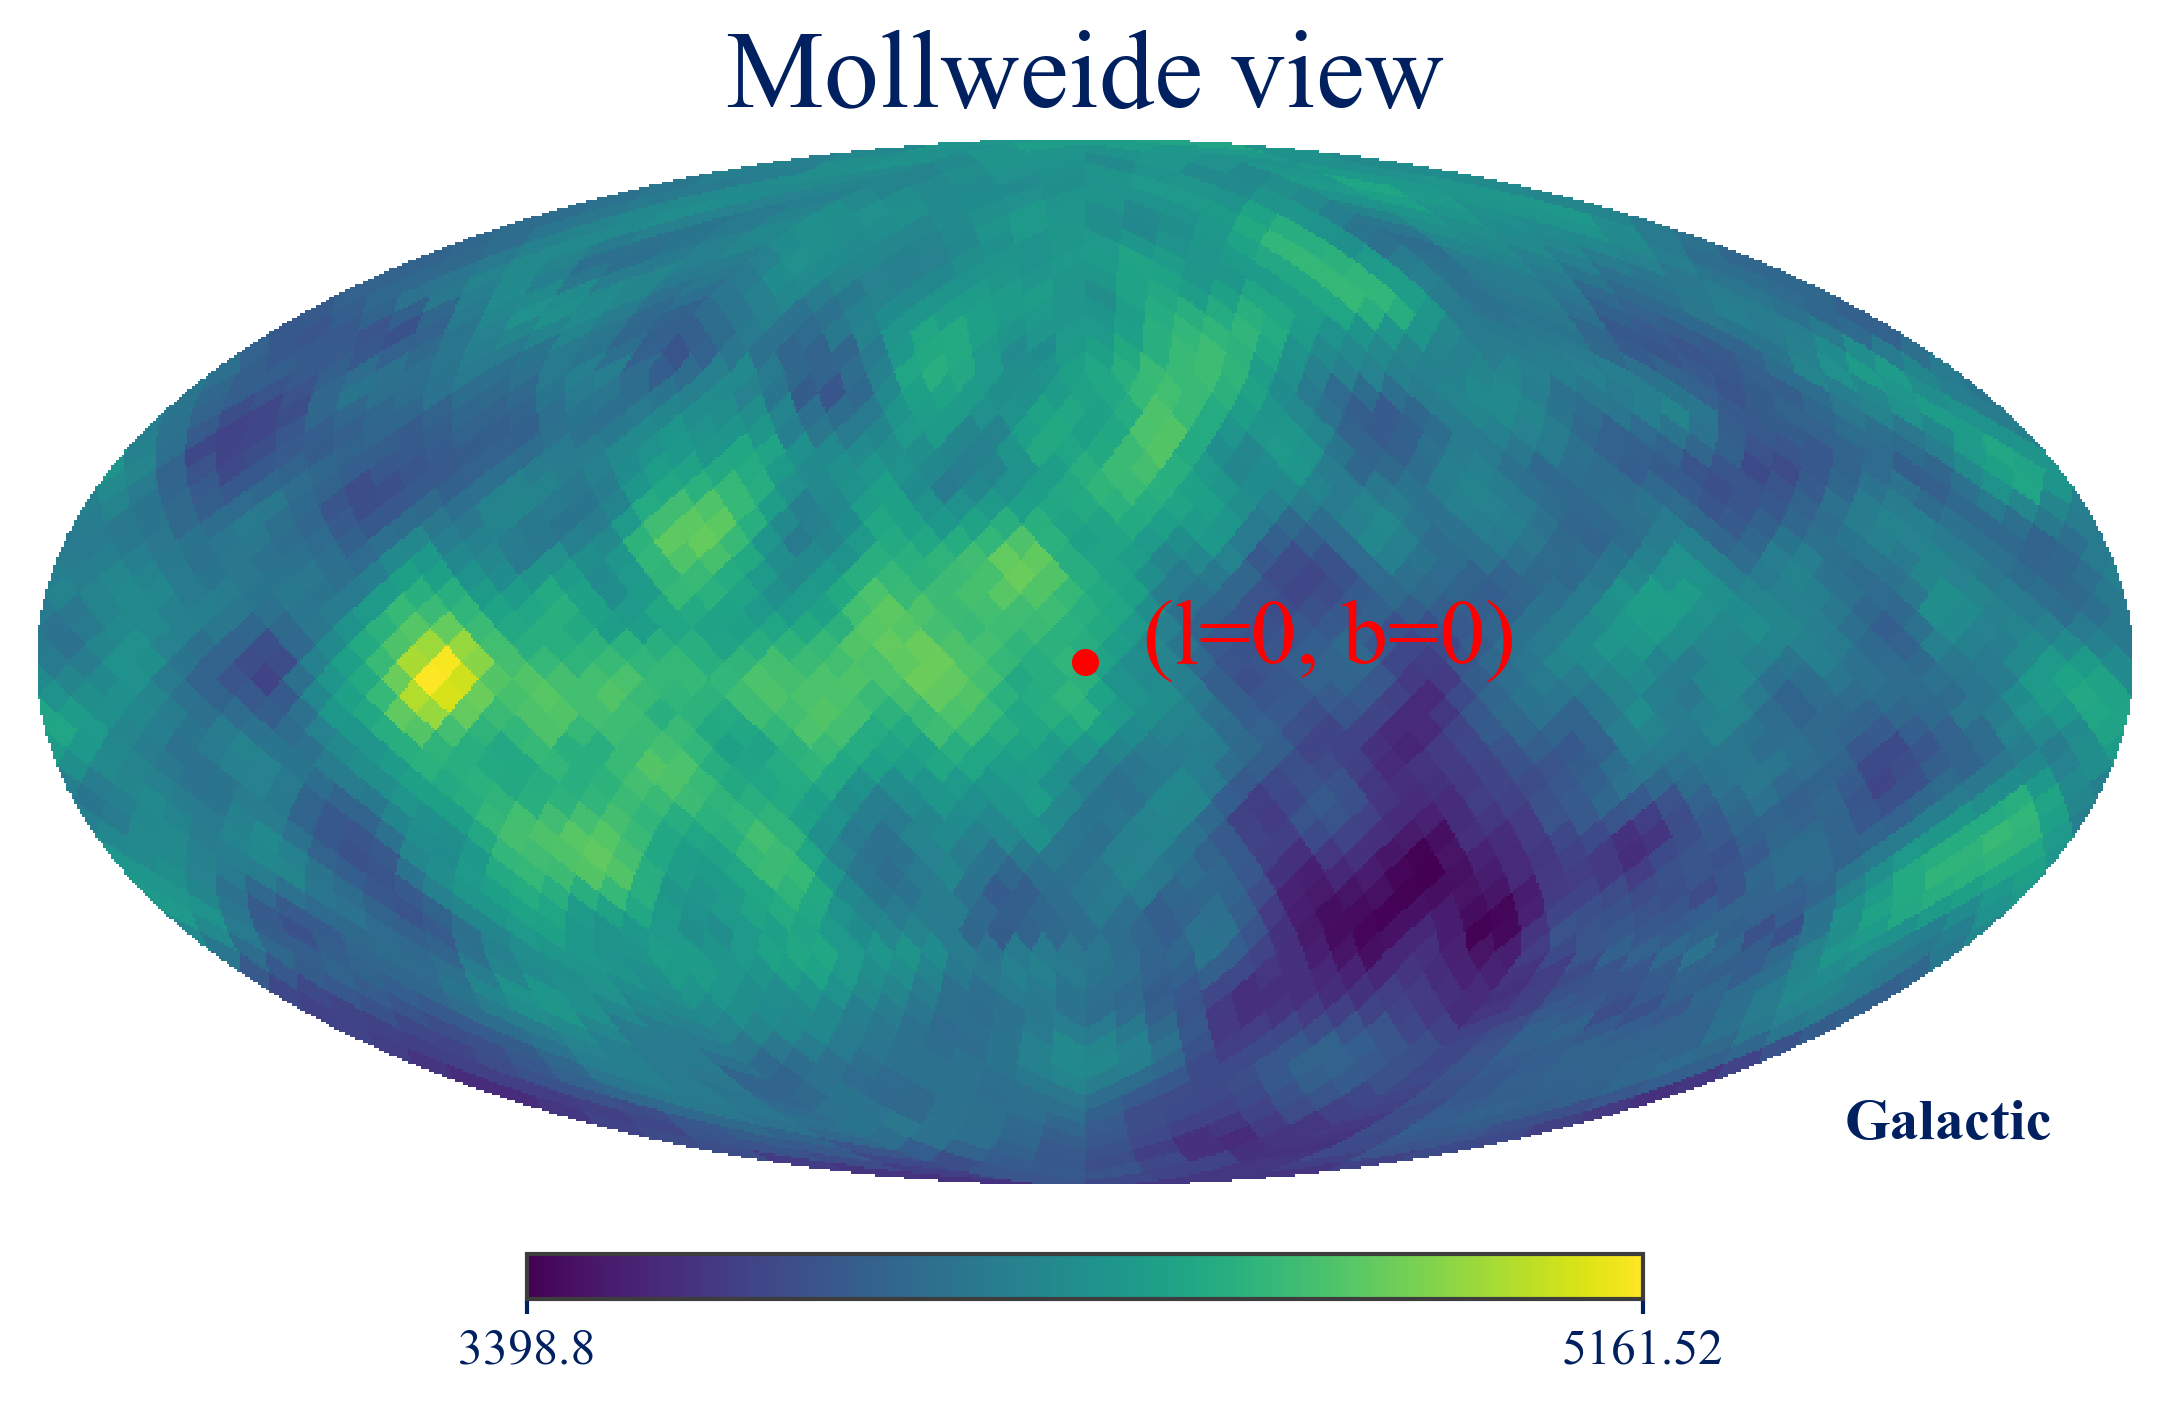

In [ ]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.4*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

506.49707217780997
1359


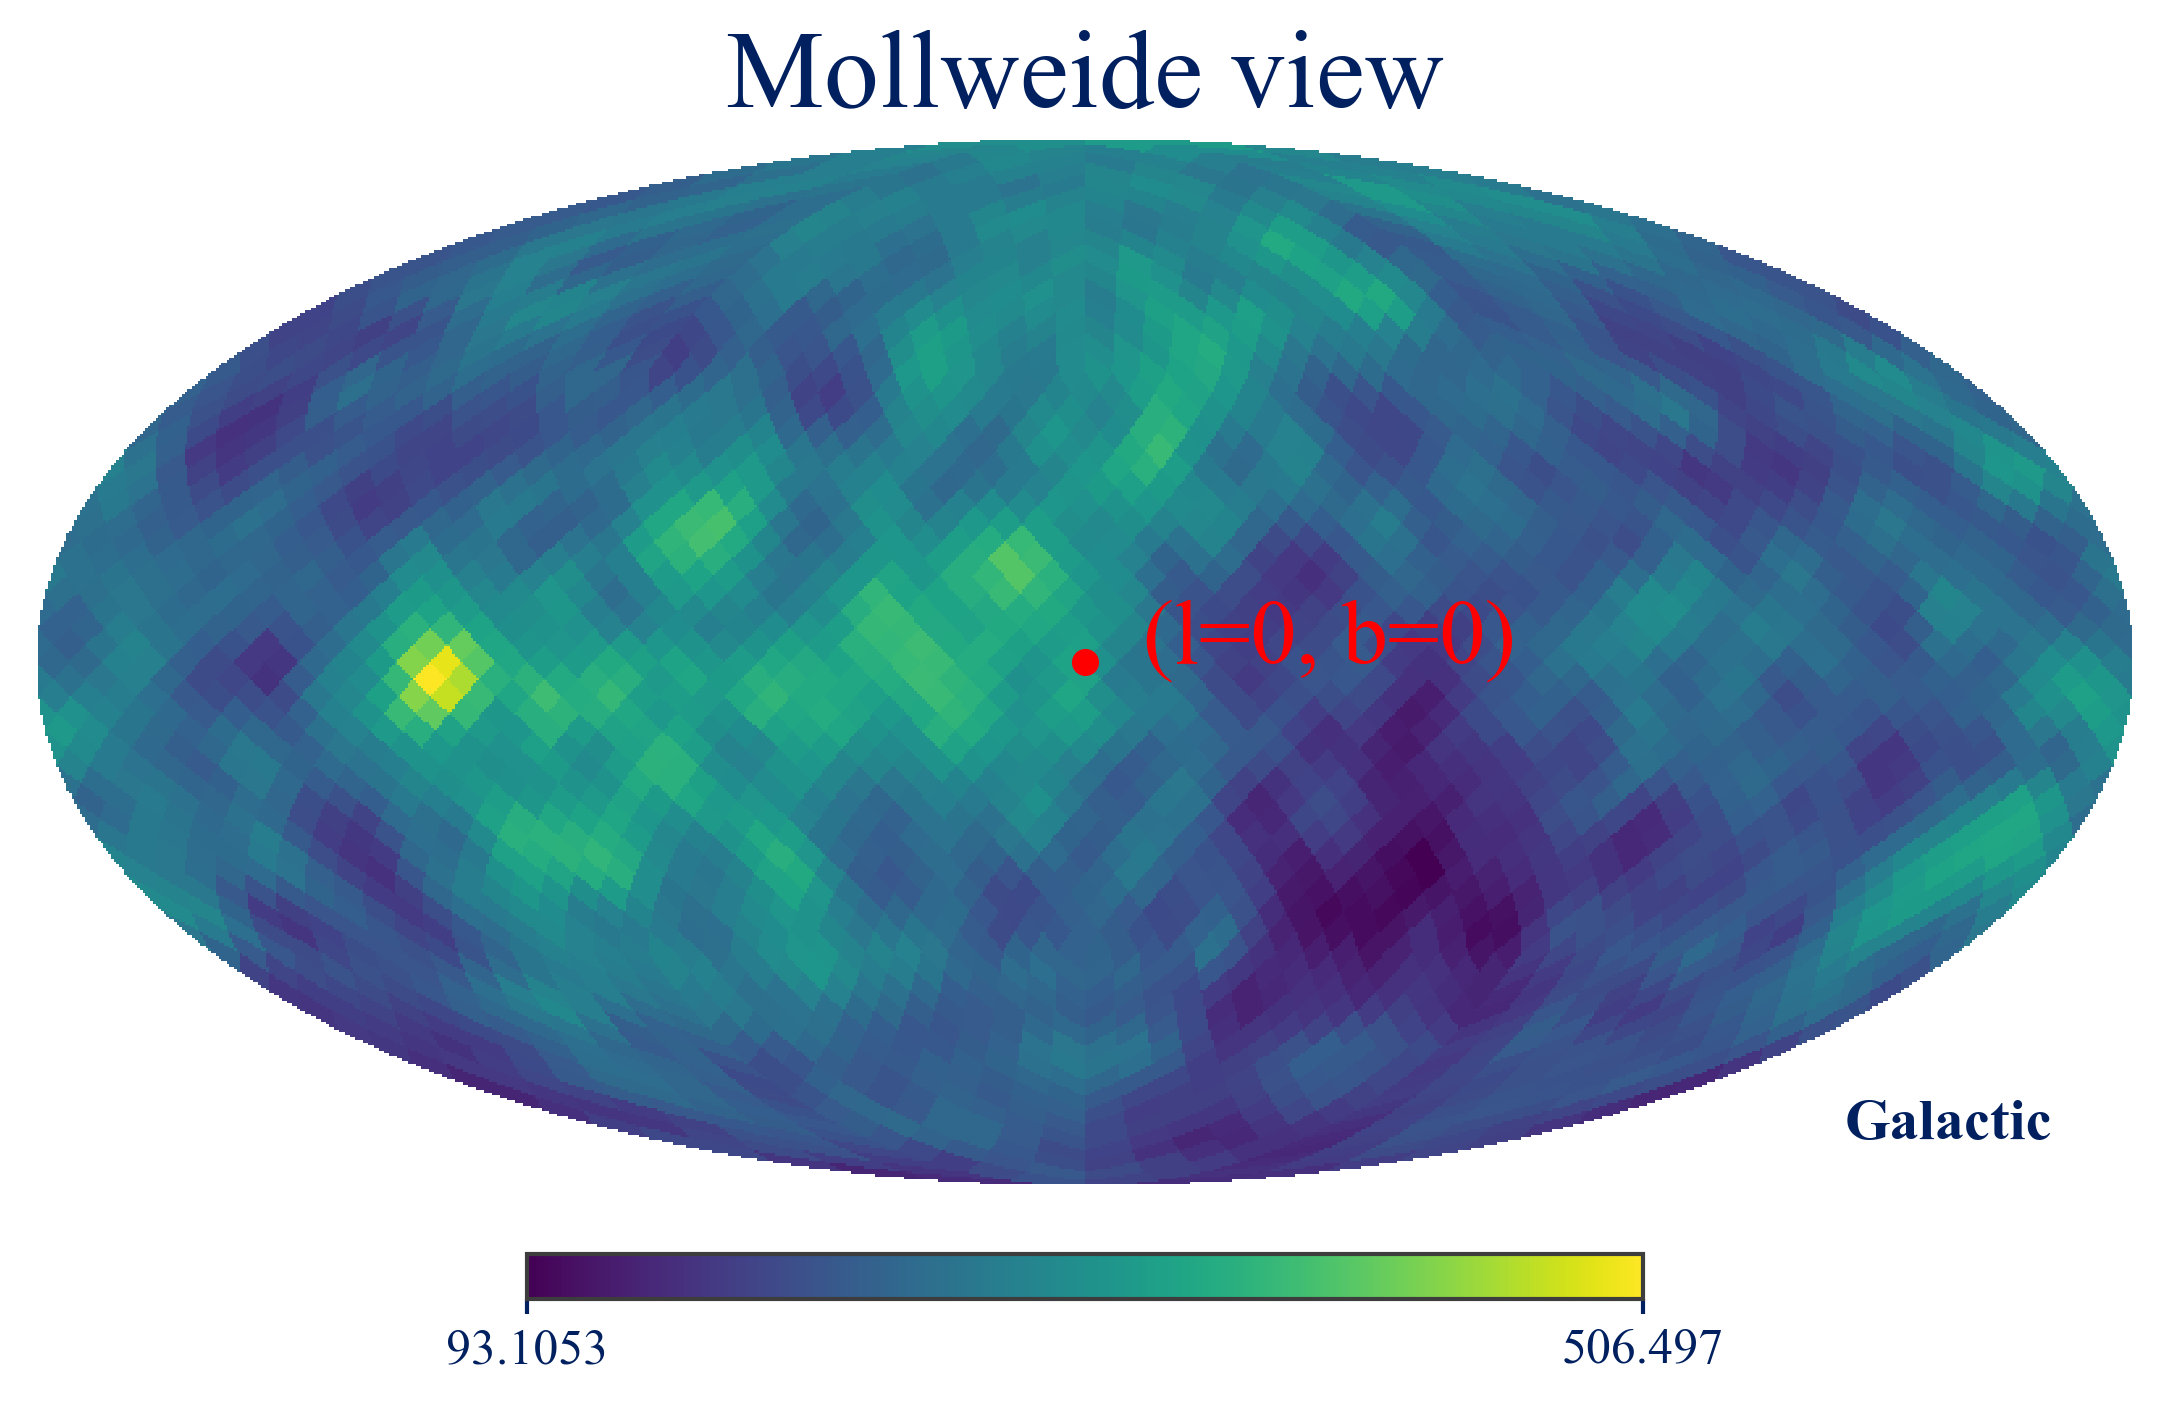

In [420]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)